In [ ]:
!pip install gdown

In [ ]:
!gdown --folder https://drive.google.com/drive/folders/10d9h-nkQccHtRzF7LNYCpVJJbTKYLJZd

Retrieving folder contents
Processing file 1GoPXqLonDMHexMxj3kFPmdEMWcGvsTdD customers.csv
Processing file 1jZer3WAU5ujvSrh0CTpAnbEtdrdFAg4u geography.csv
Processing file 1x2OZh7hsEWmAcZQ0gbstFsByUR7L8KFG inventory.csv
Processing file 14bioCPsSsjVxyd-Nuwk9uwDNBuohG5RU order_items.csv
Processing file 1Ms--H35488by0N-iizz5C3RO_HG3ktAq orders.csv
Processing file 1ou5pmFy7QLhEeD4UTV8QWbR7ZfcvICDJ payments.csv
Processing file 12-mm59bVMA2b_etM45oXKaNW0YAbeywi products.csv
Processing file 15dtEGBJWIRDFvi7q8KXXiKLGn6lVT-gG promotions.csv
Processing file 1zQeGKus1syF-klRuMyRGaIWn0TrpgDmm returns.csv
Processing file 1d1KHOtTJTlHdRlTFEXfzzhoZRiA9U8o_ reviews.csv
Processing file 1eZbLDHCuF1VXRt0QRdmPtdrEXZoAImhv sales.csv
Processing file 1OESeaSUJNXnomPAVD1XtoTlY8N7lnmyY sample_submission.csv
Processing file 1qGmVXbMIj1sfzfve3iB3YkaNEoF86W9t shipments.csv
Processing file 1vT4TF7GXXkh_HQibZiCp-HdJ2K14JVps web_traffic.csv
Retrieving folder contents completed
Building directory structure
Building di

In [ ]:
# CELL 1 — Import thu vien
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# CELL 2 — Load & prep data
# ============================================================
data_path = "/content/Data"

sales       = pd.read_csv(f"{data_path}/sales.csv",       parse_dates=['Date'])
orders      = pd.read_csv(f"{data_path}/orders.csv",      parse_dates=['order_date'])
order_items = pd.read_csv(f"{data_path}/order_items.csv", low_memory=False)
returns     = pd.read_csv(f"{data_path}/returns.csv")
products    = pd.read_csv(f"{data_path}/products.csv")
inventory   = pd.read_csv(f"{data_path}/inventory.csv")

sales = sales.sort_values('Date').reset_index(drop=True)
returns['refund_amount'] = returns['refund_amount'].fillna(0)

order_items['line_total'] = order_items['quantity'] * order_items['unit_price']
order_items['has_promo']  = (order_items['promo_id'].notnull() |
                              order_items['promo_id_2'].notnull())

order_items = order_items.merge(
    products[['product_id', 'cogs']], on='product_id', how='left')
order_items['cogs_total']   = order_items['quantity'] * order_items['cogs']
order_items['gross_profit'] = (order_items['line_total']
                                - order_items['cogs_total']
                                - order_items['discount_amount'])

In [ ]:
# CELL 3 — Pre-compute tat ca chart data & action numbers
# ============================================================

# Chart 1: Revenue Trend & Action Numbers
sales['rolling_30'] = sales['Revenue'].rolling(30).mean()

sales_before_2019 = sales[sales['Date'] < '2019-01-01']['Revenue']
sales_after_2019 = sales[sales['Date'] >= '2019-01-01']['Revenue']

mean_rev_before = sales_before_2019.mean() / 1e6
mean_rev_after = sales_after_2019.mean() / 1e6
pct_drop = (mean_rev_before - mean_rev_after) / mean_rev_before * 100

In [ ]:
# Chart 2: Waterfall
gross         = order_items['line_total'].sum()
cancelled_ids = orders[orders['order_status'] == 'cancelled']['order_id']
cancelled_rev = order_items[order_items['order_id'].isin(cancelled_ids)]['line_total'].sum()
returns_rev   = returns['refund_amount'].sum()
discounts_val = order_items['discount_amount'].sum()
net_rev       = gross - cancelled_rev - returns_rev - discounts_val

total_leakage = cancelled_rev + returns_rev + discounts_val
leakage_pct = total_leakage / gross * 100

wf_labels = ['Gross\nRevenue', f'Cancellations\n(-{cancelled_rev/gross*100:.1f}%)',
             f'Returns\n(-{returns_rev/gross*100:.1f}%)',
             f'Discounts\n(-{discounts_val/gross*100:.1f}%)', 'Net\nRevenue']
wf_heights = [gross, cancelled_rev, returns_rev, discounts_val, net_rev]
wf_colors  = ['#4ade80', '#f87171', '#f87171', '#f87171', '#60a5fa']

wf_bottoms = []
running = gross
for i, h in enumerate(wf_heights):
    if i == 0:
        wf_bottoms.append(0)
    elif i == 4:
        wf_bottoms.append(0)
    else:
        running -= h
        wf_bottoms.append(running)

In [ ]:
# Chart 3: COD Cancel Rate
cod_data = orders.groupby('payment_method').apply(
    lambda x: (x['order_status'] == 'cancelled').mean()
).sort_values(ascending=True)

cod_cancel_rate = cod_data.get('cod', 0) * 100
other_methods_rate = cod_data[cod_data.index != 'cod'].mean() * 100

In [ ]:
# Chart 4: Promo Cannibalization (COGS that)
promo_stats = order_items.groupby('has_promo').agg(
    revenue=('line_total', 'sum'),
    gross_profit=('gross_profit', 'sum'),
).reset_index()
promo_stats['gp_margin'] = promo_stats['gross_profit'] / promo_stats['revenue'] * 100
promo_rate = order_items['has_promo'].mean() * 100

margin_no_promo = promo_stats[promo_stats['has_promo'] == 0]['gp_margin'].values[0]
margin_with_promo = promo_stats[promo_stats['has_promo'] == 1]['gp_margin'].values[0]

In [ ]:
# Chart 6: Ghost Champions
snapshot    = orders['order_date'].max()
cust_orders = orders.merge(
    order_items[['order_id', 'line_total', 'discount_amount', 'gross_profit']],
    on='order_id', how='left')
cust_ret    = returns.groupby('order_id')['refund_amount'].sum().reset_index()
cust_orders = cust_orders.merge(cust_ret, on='order_id', how='left')
cust_orders['refund_amount'] = cust_orders['refund_amount'].fillna(0)

rfm = cust_orders.groupby('customer_id').agg(
    recency=('order_date',   lambda x: (snapshot - x.max()).days),
    frequency=('order_id',   'nunique'),
    monetary=('line_total',  'sum'),
    total_gp=('gross_profit','sum'),
    total_refund=('refund_amount','sum')
).reset_index()
rfm['net_contribution'] = rfm['total_gp'] - rfm['total_refund']
rfm['net_margin']       = rfm['net_contribution'] / rfm['monetary']
rfm['r'] = pd.qcut(rfm['recency'],                        5, labels=[5,4,3,2,1]).astype(int)
rfm['f'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['m'] = pd.qcut(rfm['monetary'],                       5, labels=[1,2,3,4,5]).astype(int)
rfm['rfm_score'] = rfm['r'] + rfm['f'] + rfm['m']

champions  = rfm[rfm['rfm_score'] >= 13].copy()
ghost      = champions[champions['net_margin'] < 0.05]
ghost_pct  = len(ghost) / len(champions) * 100
ghost_rev  = ghost['monetary'].sum() / champions['monetary'].sum() * 100

ghost_margin = ghost['net_margin'].mean() * 100
real_champions = champions[champions['net_margin'] >= 0.05]
real_margin = real_champions['net_margin'].mean() * 100

rfm['segment_rfm'] = pd.cut(rfm['rfm_score'], bins=[0,6,9,11,13,15],
    labels=['Lost','At-Risk','Potential','Loyal','Champions'])
margin_by_seg = rfm.groupby('segment_rfm')['net_margin'].mean() * 100

In [ ]:
# CELL 4 — Style config
# ============================================================
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'axes.facecolor':     '#f8fafc',
    'figure.facecolor':   '#ffffff',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'axes.grid':          True,
    'grid.color':         '#e2e8f0',
    'grid.linewidth':     0.6,
    'axes.labelcolor':    '#475569',
    'xtick.color':        '#64748b',
    'ytick.color':        '#64748b',
    'text.color':         '#1e293b',
})

C_RED    = '#f87171'
C_GREEN  = '#4ade80'
C_BLUE   = '#60a5fa'
C_GRAY   = '#94a3b8'
C_DARK   = '#1e293b'
C_ACCENT = '#0ea5e9'
C_ORANGE = '#fb923c'

def chart_title(ax, title, subtitle=''):
    ax.set_title(title, fontsize=11, fontweight='bold',
                 color=C_DARK, loc='left', pad=10)
    if subtitle:
        ax.annotate(subtitle, xy=(0, 1.035), xycoords='axes fraction',
                    fontsize=8, color=C_GRAY, ha='left')

def action_box(ax, text, color='#1e3a5f', bg='#eff6ff', border='#60a5fa'):
    ax.annotate(text, xy=(0, -0.20), xycoords='axes fraction',
                fontsize=7.8, color=color,
                bbox=dict(facecolor=bg, edgecolor=border,
                          boxstyle='round,pad=0.35', linewidth=0.8))

def insight_box(ax, text, color='#92400e', bg='#fef9ec', border='#f59e0b'):
    ax.annotate(text, xy=(0, -0.20), xycoords='axes fraction',
                fontsize=7.8, color=color,
                bbox=dict(facecolor=bg, edgecolor=border,
                          boxstyle='round,pad=0.35', linewidth=0.8))



In [ ]:
# Chart 5: Scatter (COGS that)
inv_latest = inventory[inventory['snapshot_date'] == inventory['snapshot_date'].max()]
seg_inv    = inv_latest.groupby('segment')['days_of_supply'].mean()
seg_rev    = order_items.merge(
    products[['product_id', 'segment']], on='product_id', how='left')
seg_m = seg_rev.groupby('segment').agg(
    revenue=('line_total', 'sum'),
    gross_profit=('gross_profit', 'sum'),
    promo_rate=('has_promo', 'mean')
).reset_index()
total_rev = seg_m['revenue'].sum()
seg_m['rev_share']   = seg_m['revenue'] / total_rev * 100
seg_m['gp_margin']   = seg_m['gross_profit'] / seg_m['revenue'] * 100
seg_m['days_supply'] = seg_m['segment'].map(seg_inv)

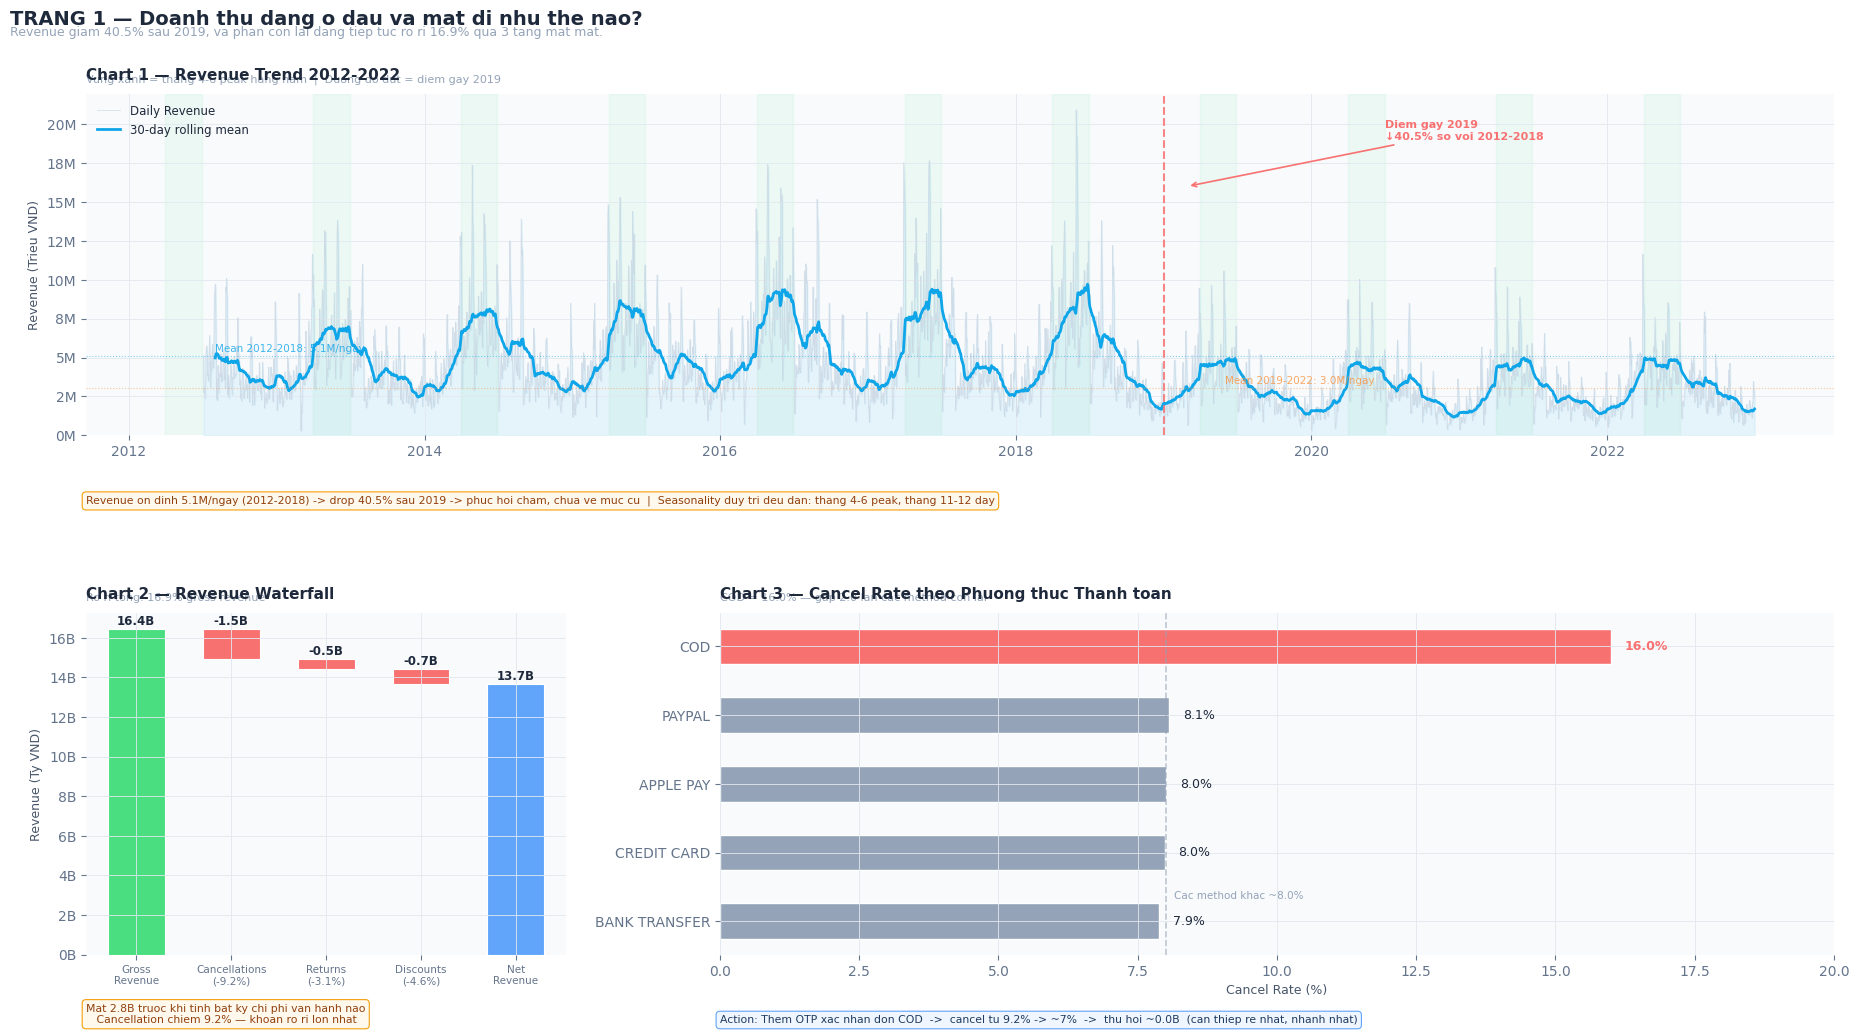

In [ ]:
# CELL 5 — Trang 1
# ============================================================
fig1 = plt.figure(figsize=(19, 10.5))
fig1.patch.set_facecolor('#ffffff')
fig1.suptitle('TRANG 1 — Doanh thu dang o dau va mat di nhu the nao?',
              fontsize=14, fontweight='bold', color=C_DARK,
              x=0.015, ha='left', y=0.99)
fig1.text(0.015, 0.965,
          f'Revenue giam {pct_drop:.1f}% sau 2019, va phan con lai dang tiep tuc ro ri {leakage_pct:.1f}% qua 3 tang mat mat.',
          fontsize=9, color=C_GRAY, ha='left')

gs1 = gridspec.GridSpec(2, 3, figure=fig1,
                         hspace=0.52, wspace=0.32,
                         top=0.91, bottom=0.09,
                         left=0.055, right=0.975)

# Chart 1: Revenue Trend
ax1 = fig1.add_subplot(gs1[0, :])

ax1.fill_between(sales['Date'], sales['Revenue'] / 1e6,
                  alpha=0.08, color=C_ACCENT)
ax1.plot(sales['Date'], sales['Revenue'] / 1e6,
          color='#cbd5e1', linewidth=0.6, alpha=0.7, label='Daily Revenue')
ax1.plot(sales['Date'], sales['rolling_30'] / 1e6,
          color=C_ACCENT, linewidth=2.0, label='30-day rolling mean')

for yr in range(2012, 2023):
    ax1.axvspan(pd.Timestamp(f'{yr}-04-01'),
                pd.Timestamp(f'{yr}-06-30'),
                alpha=0.07, color=C_GREEN, zorder=0)

ax1.axvline(pd.Timestamp('2019-01-01'), color=C_RED,
             linewidth=1.5, linestyle='--', alpha=0.85, zorder=3)
ax1.annotate(f'Diem gay 2019\n↓{pct_drop:.1f}% so voi 2012-2018',
             xy=(pd.Timestamp('2019-03-01'), 16),
             xytext=(pd.Timestamp('2020-07-01'), 19),
             fontsize=8, color=C_RED, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=C_RED, lw=1.2),
             zorder=4)

ax1.axhline(mean_rev_before, color=C_ACCENT, linewidth=0.8, linestyle=':', alpha=0.5)
ax1.text(pd.Timestamp('2012-08-01'), mean_rev_before + 0.3,
         f'Mean 2012-2018: {mean_rev_before:.1f}M/ngay', fontsize=7.5, color=C_ACCENT, alpha=0.8)
ax1.axhline(mean_rev_after, color=C_ORANGE, linewidth=0.8, linestyle=':', alpha=0.5)
ax1.text(pd.Timestamp('2019-06-01'), mean_rev_after + 0.3,
         f'Mean 2019-2022: {mean_rev_after:.1f}M/ngay', fontsize=7.5, color=C_ORANGE, alpha=0.8)

ax1.set_ylabel('Revenue (Trieu VND)', fontsize=9)
ax1.set_xlabel('')
ax1.set_ylim(bottom=0)
ax1.legend(fontsize=8.5, framealpha=0, loc='upper left')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
chart_title(ax1, 'Chart 1 — Revenue Trend 2012-2022',
            'Vung xanh = thang 4-6 peak hang nam  |  Duong do dut = diem gay 2019')
insight_box(ax1,
    f'Revenue on dinh {mean_rev_before:.1f}M/ngay (2012-2018) -> drop {pct_drop:.1f}% sau 2019 -> '
    'phuc hoi cham, chua ve muc cu  |  Seasonality duy tri deu dan: thang 4-6 peak, thang 11-12 day')

# Chart 2: Waterfall
ax2 = fig1.add_subplot(gs1[1, 0])

x2 = np.arange(len(wf_labels))
b2 = ax2.bar(x2, [h/1e9 for h in wf_heights],
              bottom=[b/1e9 for b in wf_bottoms],
              color=wf_colors, width=0.6,
              edgecolor='white', linewidth=0.8)
for bar, h in zip(b2, wf_heights):
    ypos = bar.get_y() + bar.get_height()
    sign = '' if h == wf_heights[0] or h == wf_heights[-1] else '-'
    ax2.text(bar.get_x() + bar.get_width()/2,
             ypos + (0.1 if ypos >= 0 else -0.35),
             f'{sign}{h/1e9:.1f}B',
             ha='center', va='bottom' if ypos >= 0 else 'top',
             fontsize=8.5, fontweight='bold', color=C_DARK)

ax2.set_xticks(x2)
ax2.set_xticklabels(wf_labels, fontsize=7.5)
ax2.set_ylabel('Revenue (Ty VND)', fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}B'))
chart_title(ax2, 'Chart 2 — Revenue Waterfall',
            f'Ro ri tong: {leakage_pct:.1f}% gross revenue')
insight_box(ax2, f'Mat {total_leakage/1e9:.1f}B truoc khi tinh bat ky chi phi van hanh nao\n'
                  f'   Cancellation chiem {cancelled_rev/gross*100:.1f}% — khoan ro ri lon nhat')

# Chart 3: COD Cancel Rate
ax3 = fig1.add_subplot(gs1[1, 1:])

methods3 = [m.replace('_', ' ').upper() for m in cod_data.index]
rates3   = cod_data.values * 100
colors3  = [C_RED if 'COD' in m else C_GRAY for m in methods3]

b3 = ax3.barh(methods3, rates3, color=colors3,
               height=0.52, edgecolor='white')
for bar, rate in zip(b3, rates3):
    ax3.text(rate + 0.25,
             bar.get_y() + bar.get_height()/2,
             f'{rate:.1f}%',
             va='center', fontsize=9,
             fontweight='bold' if rate > 10 else 'normal',
             color=C_RED if rate > 10 else C_DARK)

ax3.axvline(8.0, color=C_GRAY, linewidth=1.2,
             linestyle='--', alpha=0.6)
ax3.text(8.15, 0.3, f'Cac method khac ~{other_methods_rate:.1f}%',
          fontsize=7.5, color=C_GRAY, va='bottom')

ax3.set_xlabel('Cancel Rate (%)', fontsize=9)
ax3.set_xlim(0, 20)
chart_title(ax3, 'Chart 3 — Cancel Rate theo Phuong thuc Thanh toan',
            f'COD = {cod_cancel_rate:.1f}% — gap {cod_cancel_rate/other_methods_rate:.1f} lan cac method con lai')
action_box(ax3,
    f'Action: Them OTP xac nhan don COD  ->  cancel tu {cancelled_rev/gross*100:.1f}% -> ~7%  ->  thu hoi ~{(cancelled_rev/gross*0.022)*gross/1e9:.1f}B  '
    '(can thiep re nhat, nhanh nhat)')

plt.savefig('trang_1_eda.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

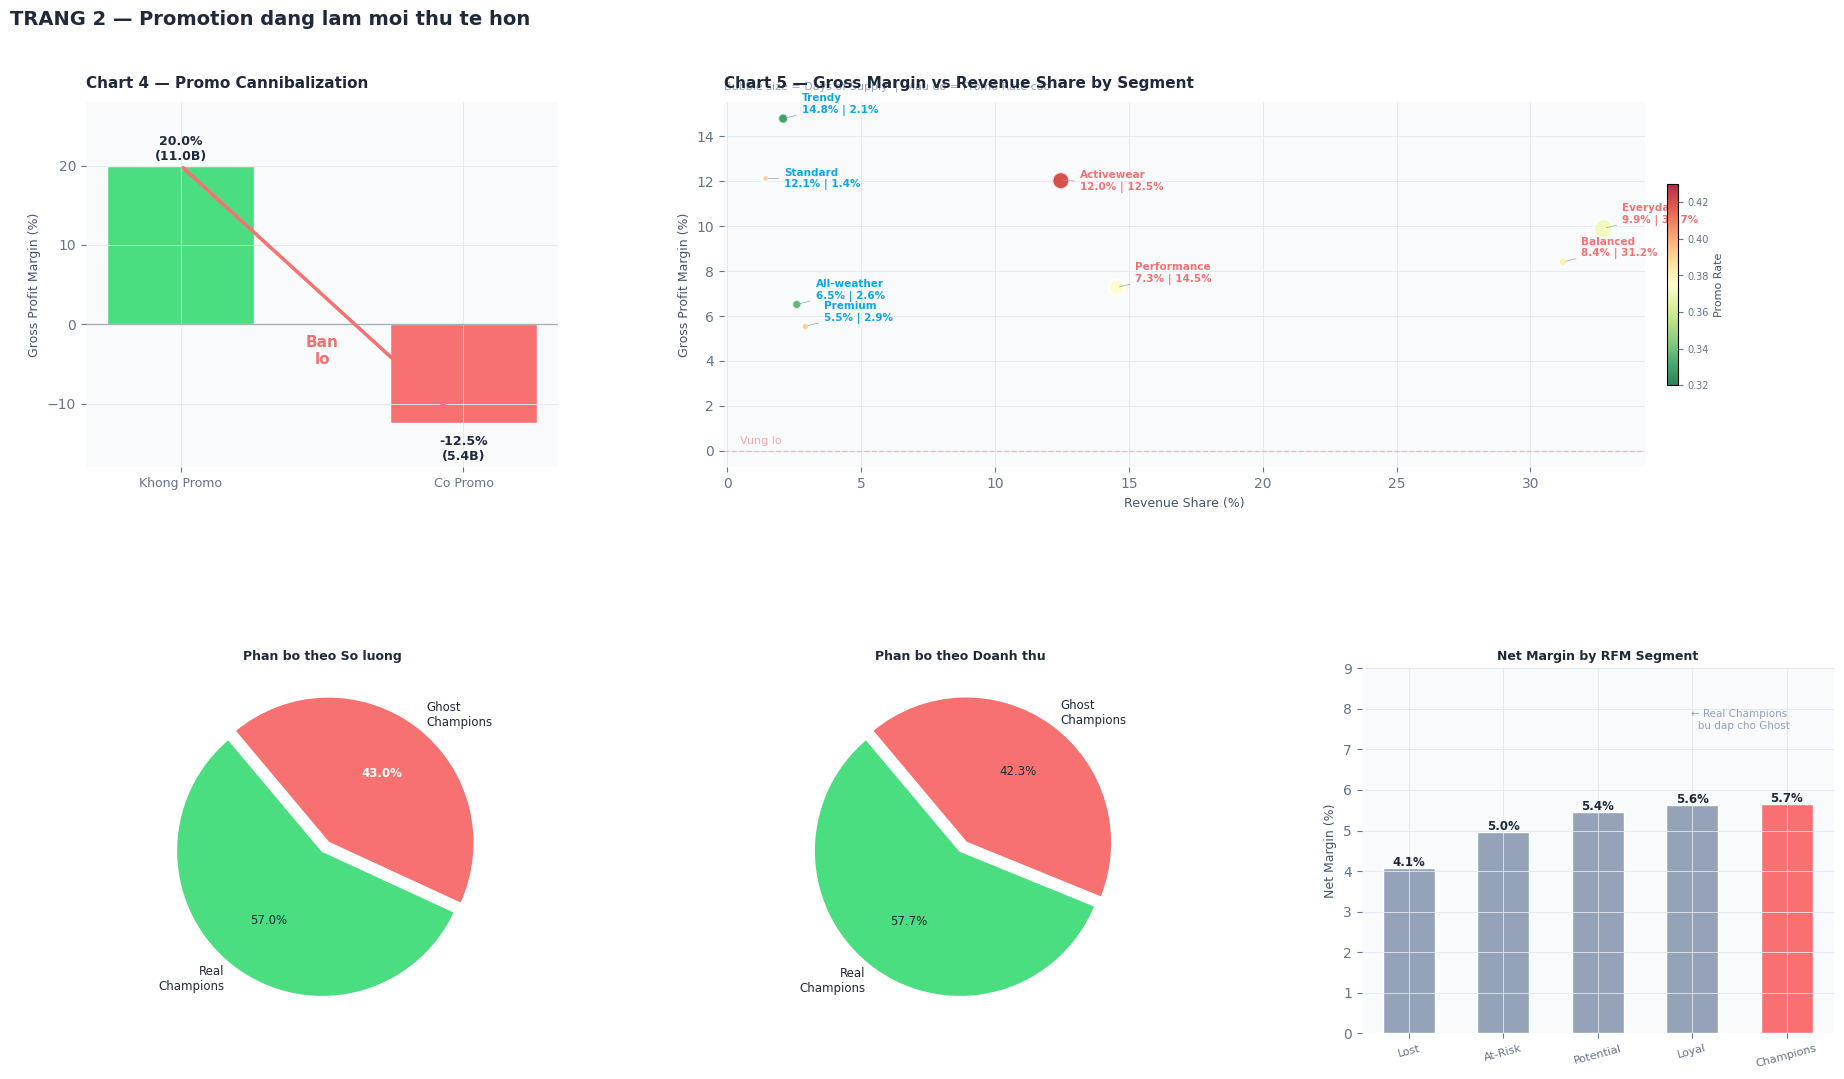

In [ ]:
# CELL 6 — Trang 2
# ============================================================
fig2 = plt.figure(figsize=(19, 11.5))
fig2.patch.set_facecolor('#ffffff')
fig2.suptitle('TRANG 2 — Promotion dang lam moi thu te hon',
              fontsize=14, fontweight='bold', color=C_DARK,
              x=0.015, ha='left', y=0.99)

gs2 = gridspec.GridSpec(2, 3, figure=fig2,
                         hspace=0.55, wspace=0.35,
                         top=0.91, bottom=0.10,
                         left=0.055, right=0.975)

# Chart 4: Promo Cannibalization
ax4 = fig2.add_subplot(gs2[0, 0])

margins4 = promo_stats['gp_margin'].values
revs4    = promo_stats['revenue'].values / 1e9
labels4  = ['Khong Promo', 'Co Promo']
colors4  = [C_GREEN, C_RED]

b4 = ax4.bar([0, 1], margins4, color=colors4,
              width=0.52, edgecolor='white')

for bar, m, r in zip(b4, margins4, revs4):
    ypos = bar.get_y() + bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2,
             ypos + (0.4 if m > 0 else -1.5),
             f'{m:.1f}%\n({r:.1f}B)',
             ha='center', fontsize=9, fontweight='bold',
             color=C_DARK, va='bottom' if m > 0 else 'top')

ax4.annotate('', xy=(1, margins4[1]), xytext=(0, margins4[0]),
             arrowprops=dict(arrowstyle='->', color=C_RED, lw=2.5))
ax4.text(0.5, -5,
         f'Ban\nlo', ha='center',
         fontsize=11, color=C_RED, fontweight='bold')
ax4.axhline(0, color=C_DARK, linewidth=1, alpha=0.3)

ax4.set_xticks([0, 1])
ax4.set_xticklabels(labels4, fontsize=9)
ax4.set_ylabel('Gross Profit Margin (%)', fontsize=9)
ax4.set_ylim(-18, 28)
chart_title(ax4, 'Chart 4 — Promo Cannibalization')
# Chart 5: Scatter
ax5 = fig2.add_subplot(gs2[0, 1:])

bubble = seg_m['days_supply'].fillna(500) / 18
sc = ax5.scatter(
    seg_m['rev_share'], seg_m['gp_margin'],
    s=bubble,
    c=seg_m['promo_rate'],
    cmap='RdYlGn_r',
    alpha=0.82,
    edgecolors='white', linewidth=1.8,
    vmin=0.32, vmax=0.43, zorder=3)

for _, row in seg_m.iterrows():
    is_problem = row['rev_share'] > 10
    dx = 0.7
    dy = 0.25 if row['segment'] not in ['Activewear','Standard'] else -0.4
    ax5.annotate(
        f"{row['segment']}\n{row['gp_margin']:.1f}% | {row['rev_share']:.1f}%",
        xy=(row['rev_share'], row['gp_margin']),
        xytext=(row['rev_share'] + dx, row['gp_margin'] + dy),
        fontsize=7.5, fontweight='bold',
        color=C_RED if is_problem else C_ACCENT,
        arrowprops=dict(arrowstyle='-', color=C_GRAY, lw=0.5))

ax5.axhline(0, color=C_RED, linewidth=1, linestyle='--', alpha=0.4)
ax5.text(0.5, 0.3, 'Vung lo', color=C_RED, fontsize=8, alpha=0.6)

cbar = plt.colorbar(sc, ax=ax5, shrink=0.55, pad=0.02)
cbar.set_label('Promo Rate', fontsize=8)
cbar.ax.tick_params(labelsize=7)
ax5.set_xlabel('Revenue Share (%)', fontsize=9)
ax5.set_ylabel('Gross Profit Margin (%)', fontsize=9)
chart_title(ax5, 'Chart 5 — Gross Margin vs Revenue Share by Segment',
            'Bubble size = Days of Supply  |  Mau do = Promo Rate cao')

# Chart 6: Ghost Champions
ax6a = fig2.add_subplot(gs2[1, 0])
ax6b = fig2.add_subplot(gs2[1, 1])
ax6c = fig2.add_subplot(gs2[1, 2])

# 6a: Pie so luong
pie_c = [C_GREEN, C_RED]
exp   = [0, 0.07]
w, t, at = ax6a.pie(
    [100-ghost_pct, ghost_pct],
    labels=['Real\nChampions', 'Ghost\nChampions'],
    colors=pie_c, explode=exp,
    autopct='%1.1f%%', startangle=130,
    textprops={'fontsize': 8.5},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
at[1].set_color('white')
at[1].set_fontweight('bold')
ax6a.set_title('Phan bo theo So luong',
               fontsize=9, fontweight='bold', color=C_DARK, pad=6)

# 6b: Pie doanh thu
ax6b.pie(
    [100-ghost_rev, ghost_rev],
    labels=['Real\nChampions', 'Ghost\nChampions'],
    colors=pie_c, explode=exp,
    autopct='%1.1f%%', startangle=130,
    textprops={'fontsize': 8.5},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax6b.set_title('Phan bo theo Doanh thu',
               fontsize=9, fontweight='bold', color=C_DARK, pad=6)

# 6c: Net margin by segment
seg_names   = margin_by_seg.index.tolist()
seg_margins = margin_by_seg.values
c6c = [C_RED if s == 'Champions' else C_GRAY for s in seg_names]
b6c = ax6c.bar(seg_names, seg_margins, color=c6c,
                width=0.55, edgecolor='white')
for bar, m in zip(b6c, seg_margins):
    ax6c.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.05,
              f'{m:.1f}%',
              ha='center', fontsize=8.5,
              fontweight='bold', color=C_DARK)
ax6c.set_ylabel('Net Margin (%)', fontsize=9)
ax6c.tick_params(axis='x', labelrotation=15, labelsize=8)
ax6c.set_ylim(0, 9)
ax6c.set_title('Net Margin by RFM Segment',
               fontsize=9, fontweight='bold', color=C_DARK, pad=6)
ax6c.text(3.5, 7.5,
          '← Real Champions\n   bu dap cho Ghost',
          fontsize=7.5, color=C_GRAY, ha='center')


plt.savefig('trang_2_eda.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# ========== LẤY SỐ CHO POWER BI ==========

print("=== CHART 2 — WATERFALL ===")
print(f"Gross Revenue:     {gross/1e9:.4f}B  →  {gross:.0f}")
print(f"Cancelled:        -{cancelled_rev/1e9:.4f}B  →  -{cancelled_rev:.0f}")
print(f"Returns:          -{returns_rev/1e9:.4f}B  →  -{returns_rev:.0f}")
print(f"Discounts:        -{discounts_val/1e9:.4f}B  →  -{discounts_val:.0f}")
print(f"Net Revenue:       {net_rev/1e9:.4f}B  →  {net_rev:.0f}")

print("\n=== CHART 3 — CANCEL RATE BY PAYMENT METHOD ===")
cancel_by_payment = orders.groupby('payment_method').apply(
    lambda x: (x['order_status'] == 'cancelled').mean() * 100
).reset_index()
cancel_by_payment.columns = ['payment_method', 'cancel_rate']
print(cancel_by_payment.sort_values('cancel_rate', ascending=False).to_string(index=False))

print("\n=== CHART 4 — GP MARGIN PROMO vs NO PROMO ===")
print(f"GP Margin No Promo:   {margin_no_promo:.4f}%")
print(f"GP Margin With Promo: {margin_with_promo:.4f}%")
print(f"Promo Rate:           {promo_rate:.4f}%")

print("\n=== CHART 5 — SCATTER SEGMENT ===")
print(seg_m[['segment','revenue','gp_margin','promo_rate','days_supply']].to_string(index=False))
total_rev = seg_m['revenue'].sum()
seg_m['rev_share'] = seg_m['revenue'] / total_rev * 100
print(seg_m[['segment','rev_share','gp_margin','promo_rate','days_supply']].to_string(index=False))
print("\n=== CHART 6 — GHOST CHAMPIONS ===")
print(margin_by_seg.reset_index().to_string(index=False))

=== CHART 2 — WATERFALL ===
Gross Revenue:     16.4305B  →  16430476586
Cancelled:        -1.5159B  →  -1515891006
Returns:          -0.5106B  →  -510598507
Discounts:        -0.7496B  →  -749607320
Net Revenue:       13.6544B  →  13654379753

=== CHART 3 — CANCEL RATE BY PAYMENT METHOD ===
payment_method  cancel_rate
           cod    15.999007
        paypal     8.057268
     apple_pay     8.013835
   credit_card     7.984240
 bank_transfer     7.889577

=== CHART 4 — GP MARGIN PROMO vs NO PROMO ===
GP Margin No Promo:   19.9637%
GP Margin With Promo: -12.4663%
Promo Rate:           38.6635%

=== CHART 5 — SCATTER SEGMENT ===
    segment      revenue  gp_margin  promo_rate  days_supply
 Activewear 2.047815e+09  12.029384    0.419733  2825.271154
All-weather 4.275845e+08   6.513117    0.336553   869.950000
   Balanced 5.127409e+09   8.410410    0.381330   713.247458
   Everyday 5.376849e+09   9.897522    0.371155  3319.047222
Performance 2.390412e+09   7.266272    0.374506  2212.48200

998682.16602

Retrieving folder contents
Processing file 1GoPXqLonDMHexMxj3kFPmdEMWcGvsTdD customers.csv
Processing file 1jZer3WAU5ujvSrh0CTpAnbEtdrdFAg4u geography.csv
Processing file 1x2OZh7hsEWmAcZQ0gbstFsByUR7L8KFG inventory.csv
Processing file 14bioCPsSsjVxyd-Nuwk9uwDNBuohG5RU order_items.csv
Processing file 1Ms--H35488by0N-iizz5C3RO_HG3ktAq orders.csv
Processing file 1ou5pmFy7QLhEeD4UTV8QWbR7ZfcvICDJ payments.csv
Processing file 12-mm59bVMA2b_etM45oXKaNW0YAbeywi products.csv
Processing file 15dtEGBJWIRDFvi7q8KXXiKLGn6lVT-gG promotions.csv
Processing file 1zQeGKus1syF-klRuMyRGaIWn0TrpgDmm returns.csv
Processing file 1d1KHOtTJTlHdRlTFEXfzzhoZRiA9U8o_ reviews.csv
Processing file 1eZbLDHCuF1VXRt0QRdmPtdrEXZoAImhv sales.csv
Processing file 1OESeaSUJNXnomPAVD1XtoTlY8N7lnmyY sample_submission.csv
Processing file 1qGmVXbMIj1sfzfve3iB3YkaNEoF86W9t shipments.csv
Processing file 1vT4TF7GXXkh_HQibZiCp-HdJ2K14JVps web_traffic.csv
Retrieving folder contents completed
Building directory structure
Building di

  0%|          | 0/80 [00:00<?, ?it/s]


Best XGB CV RMSE: 1,013,477
Best params: {'n_estimators': 826, 'learning_rate': 0.010064410639975811, 'max_depth': 7, 'subsample': 0.5678499978057628, 'colsample_bytree': 0.5185571560469616, 'min_child_weight': 6, 'reg_alpha': 0.0002053868349994732, 'reg_lambda': 0.002288368240931165, 'gamma': 3.1475841098517767}


  0%|          | 0/60 [00:00<?, ?it/s]


Best LGB CV RMSE: 1,028,598

  XGBoost (tuned)
  R²   : 0.6678
  MAE  : 501,763
  RMSE : 712,374
  MAPE : 21.77%

  LightGBM (tuned)
  R²   : 0.6499
  MAE  : 516,575
  RMSE : 731,310
  MAPE : 22.45%

Ensemble weight (tối ưu trên train recent):
  XGB weight: 0.000  |  LGB weight: 1.000

  Ensemble XGB×0.00+LGB×1.00
  R²   : 0.6499
  MAE  : 516,575
  RMSE : 731,310
  MAPE : 22.45%

Top 15 features:
lag_1                      0.10
rolling_min_7              0.06
lag_365                    0.06
rolling_mean_7             0.04
lag_7                      0.03
traffic_conversion         0.02
lag_30                     0.02
rev_yoy                    0.02
pct_change_7               0.02
lag_14                     0.02
trend_7_30                 0.02
pct_change_30              0.02
rolling_max_7              0.02
sessions_growth            0.02
avg_session_duration_sec   0.02

Feature group importance:
structural   0.02
inventory    0.03
time         0.04
promo        0.04
holiday      0.05
mo

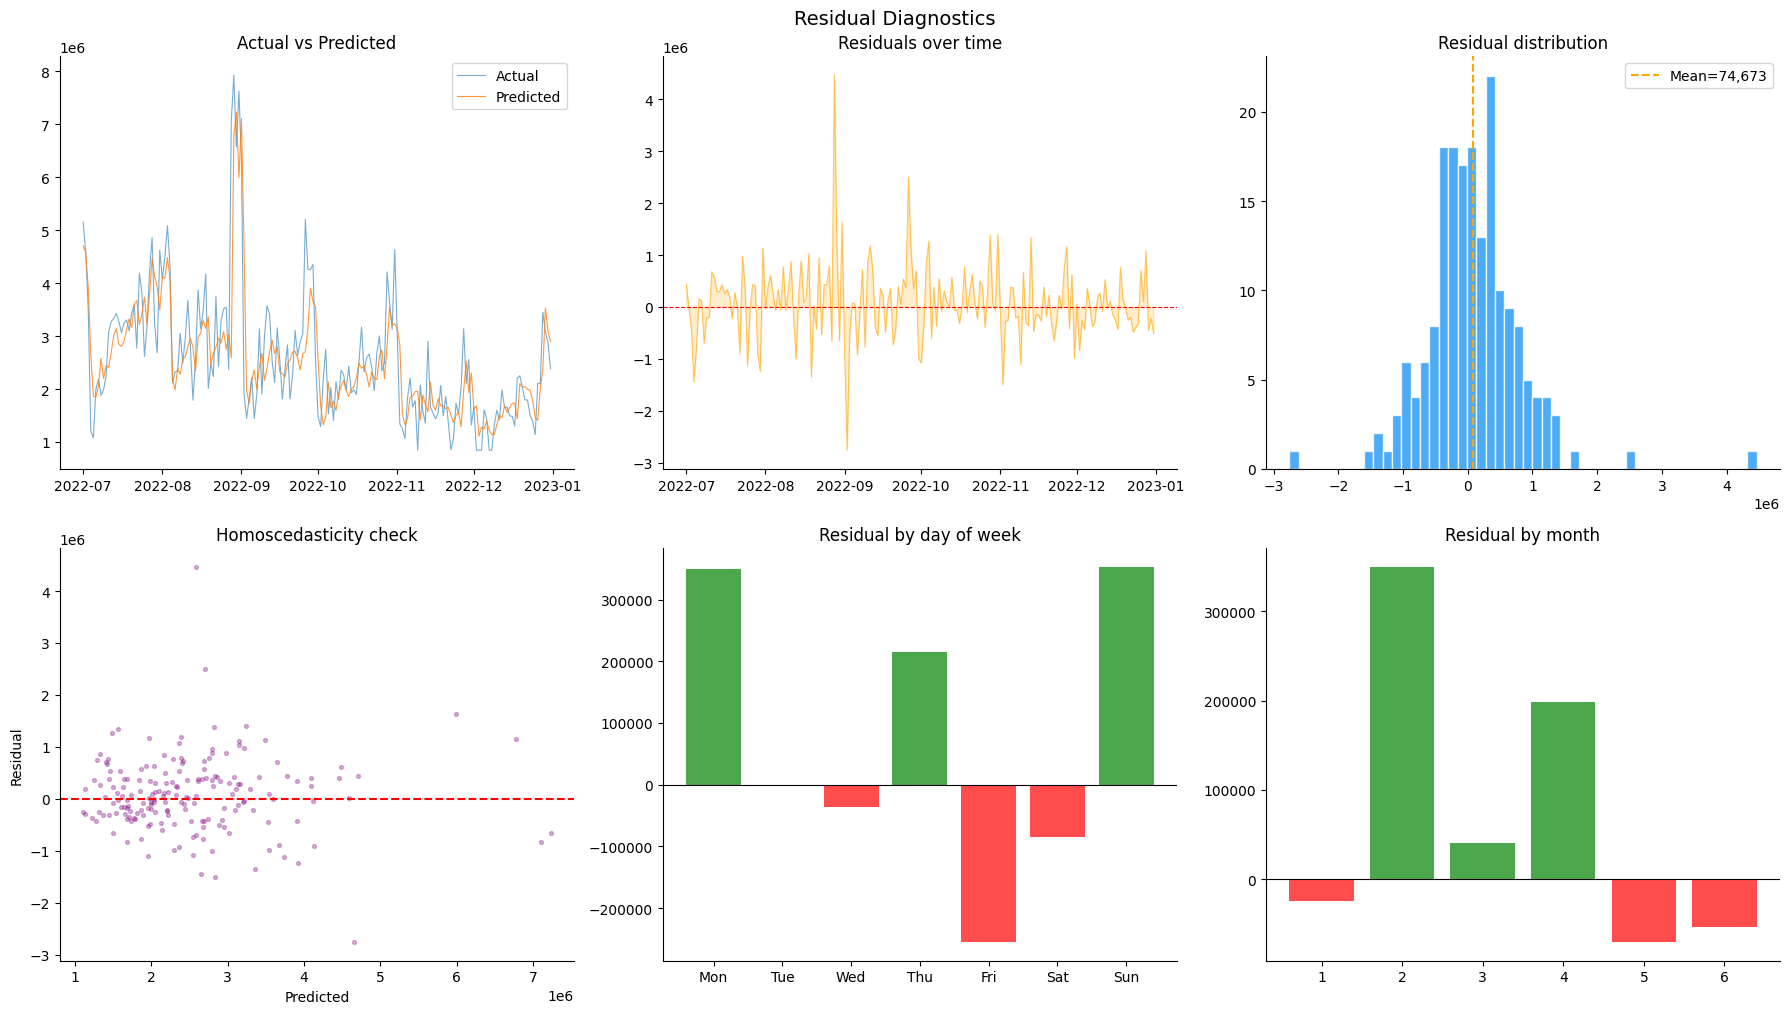


Residual summary:
  Mean  : 74,673
  Std   : 727,487
  % < 0 : 47.3%

MODEL COMPARISON
           R2        MAE       RMSE  MAPE
XGBoost  0.67 501,762.68 712,373.74 21.77
LightGBM 0.65 516,574.67 731,309.70 22.45
Ensemble 0.65 516,574.54 731,309.53 22.45
Models saved ✓
Test dates: 548 ngày | 2023-01-01 → 2024-07-01
✅ Xuất 548 dòng → submission.csv
            Date      Revenue         COGS
3833  2023-01-01 2,488,072.58 2,014,214.30
3834  2023-01-02 1,984,402.59 1,606,469.24
3835  2023-01-03 1,385,135.16 1,121,333.46
3836  2023-01-04 1,270,977.10 1,028,917.03
3837  2023-01-05 1,122,074.27   908,373.03
3838  2023-01-06 1,143,029.35   925,337.18
3839  2023-01-07 1,246,394.52 1,009,016.25
3840  2023-01-08 1,565,618.06 1,267,443.04
3841  2023-01-09 1,683,106.81 1,362,555.84
3842  2023-01-10 1,989,531.57 1,610,621.40

Revenue range: 1,122,074 – 10,216,153
COGS range  : 908,373 – 8,616,474


In [ ]:
# ============================================================
# REVENUE FORECASTING v3 — Fixed Pipeline
# Fixes từ v2:
#   1. pct_change bug với np.nan
#   2. tscv_c chưa khai báo
#   3. rev_yoy, rev_volatility_30, trend_14_30 không update trong loop
#   4. Residual feature leakage khi retrain
#   5. CUTOFF 2022-07 (6 tháng val)
#   6. Ensemble weight tối ưu trên train recent, không phải val
# ============================================================

# ============================================================
# CELL 1 — Cài đặt
# ============================================================
!pip install -q optuna lightgbm xgboost shap joblib
!pip install -q gdown
!gdown --folder https://drive.google.com/drive/folders/10d9h-nkQccHtRzF7LNYCpVJJbTKYLJZd


# ============================================================
# CELL 2 — Import
# ============================================================
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize_scalar
from xgboost import XGBRegressor
import lightgbm as lgb
import optuna
import joblib
import json
import os

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('Libraries loaded ✓')


# ============================================================
# CELL 3 — Load & Preprocess
# ============================================================
DATA_PATH = 'Data'

products    = pd.read_csv(f'{DATA_PATH}/products.csv')
customers   = pd.read_csv(f'{DATA_PATH}/customers.csv')
promotions  = pd.read_csv(f'{DATA_PATH}/promotions.csv')
geography   = pd.read_csv(f'{DATA_PATH}/geography.csv')
orders      = pd.read_csv(f'{DATA_PATH}/orders.csv')
order_items = pd.read_csv(f'{DATA_PATH}/order_items.csv', low_memory=False)
payments    = pd.read_csv(f'{DATA_PATH}/payments.csv')
shipments   = pd.read_csv(f'{DATA_PATH}/shipments.csv')
returns     = pd.read_csv(f'{DATA_PATH}/returns.csv')
reviews     = pd.read_csv(f'{DATA_PATH}/reviews.csv')
sales       = pd.read_csv(f'{DATA_PATH}/sales.csv')
inventory   = pd.read_csv(f'{DATA_PATH}/inventory.csv')
web_traffic = pd.read_csv(f'{DATA_PATH}/web_traffic.csv')


def parse_dates(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')


parse_dates(orders,      ['order_date'])
parse_dates(customers,   ['signup_date'])
parse_dates(shipments,   ['ship_date', 'delivery_date'])
parse_dates(returns,     ['return_date'])
parse_dates(reviews,     ['review_date'])
parse_dates(sales,       ['Date'])
parse_dates(web_traffic, ['date'])
parse_dates(inventory,   ['snapshot_date'])
parse_dates(promotions,  ['start_date', 'end_date'])

returns['refund_amount']         = returns['refund_amount'].fillna(0)
payments['payment_value']        = payments['payment_value'].fillna(0)
customers['age_group']           = customers['age_group'].fillna('unknown')
customers['acquisition_channel'] = customers['acquisition_channel'].fillna('unknown')

order_items['has_promo']      = (order_items['promo_id'].notnull() | order_items['promo_id_2'].notnull()).astype(int)
order_items['total_discount'] = order_items['discount_amount']
order_items = order_items[(order_items['unit_price'] > 0) & (order_items['quantity'] > 0)]
returns     = returns[returns['refund_amount'] >= 0]

def clean_text(x):
    return x.strip().lower() if isinstance(x, str) else x

products['category'] = products['category'].apply(clean_text)
products['segment']  = products['segment'].apply(clean_text)
customers['city']    = customers['city'].apply(clean_text)

order_items['line_total'] = order_items['quantity'] * order_items['unit_price']
order_items['revenue']    = order_items['line_total']
lower, upper = order_items['revenue'].quantile([0.01, 0.99])
order_items  = order_items[(order_items['revenue'] >= lower) & (order_items['revenue'] <= upper)]

print('Preprocessing done ✓')
print(f'Sales range: {sales["Date"].min().date()} → {sales["Date"].max().date()}')


# ============================================================
# CELL 4 — Feature Engineering
# ============================================================
df = sales.copy()
df = df.sort_values('Date').reset_index(drop=True)

# Clip Revenue outliers
low_r, up_r = df['Revenue'].quantile([0.01, 0.99])
df['Revenue'] = df['Revenue'].clip(low_r, up_r)


# --- 4.1 Time + Fourier ---
def add_time_features(df):
    df = df.copy()
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['month']       = df['Date'].dt.month
    df['year']        = df['Date'].dt.year
    df['quarter']     = df['Date'].dt.quarter
    df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
    df['month_day']   = df['Date'].dt.strftime('%m-%d')

    doy = df['Date'].dt.dayofyear
    dow = df['Date'].dt.dayofweek
    df['sin_week']     = np.sin(2 * np.pi * dow / 7)
    df['cos_week']     = np.cos(2 * np.pi * dow / 7)
    df['sin_year']     = np.sin(2 * np.pi * doy / 365)
    df['cos_year']     = np.cos(2 * np.pi * doy / 365)
    df['sin_biannual'] = np.sin(4 * np.pi * doy / 365)
    df['cos_biannual'] = np.cos(4 * np.pi * doy / 365)
    df['sin_quarter']  = np.sin(2 * np.pi * df['quarter'] / 4)
    df['cos_quarter']  = np.cos(2 * np.pi * df['quarter'] / 4)
    return df


# --- 4.2 Lag + Rolling ---
def add_lag_rolling(df):
    df   = df.copy()
    rev  = df['Revenue']
    rev_s = rev.shift(1)

    df['lag_1']   = rev.shift(1)
    df['lag_7']   = rev.shift(7)
    df['lag_14']  = rev.shift(14)
    df['lag_30']  = rev.shift(30)
    df['lag_365'] = rev.shift(365)

    df['rolling_mean_7']  = rev_s.rolling(7,  min_periods=1).mean()
    df['rolling_mean_14'] = rev_s.rolling(14, min_periods=1).mean()
    df['rolling_mean_30'] = rev_s.rolling(30, min_periods=1).mean()
    df['rolling_std_7']   = rev_s.rolling(7,  min_periods=2).std()
    df['rolling_std_30']  = rev_s.rolling(30, min_periods=2).std()
    df['rolling_max_7']   = rev_s.rolling(7,  min_periods=1).max()
    df['rolling_min_7']   = rev_s.rolling(7,  min_periods=1).min()

    df['trend_7_30']  = df['rolling_mean_7']  - df['rolling_mean_30']
    df['trend_14_30'] = df['rolling_mean_14'] - df['rolling_mean_30']  # FIX: đã thêm

    # FIX: dùng pd.notna thay vì `not in [np.nan]`
    df['pct_change_7']  = rev_s.pct_change(7).clip(-2, 2)
    df['pct_change_30'] = rev_s.pct_change(30).clip(-2, 2)

    df['rev_yoy'] = (rev_s / rev.shift(366) - 1).clip(-2, 2)

    df['rev_volatility_30'] = (df['rolling_std_30'] / df['rolling_mean_30'].clip(1)).fillna(0)
    df['range_ratio_7']     = ((df['rolling_max_7'] - df['rolling_min_7'])
                                / df['rolling_mean_7'].clip(1)).fillna(0)

    df['post_break']        = (df['Date'] >= '2019-01-01').astype(int)
    df['post_break_x_lag1'] = df['post_break'] * df['lag_1']
    return df


# --- 4.3 Web Traffic ---
def add_traffic_features(df, traffic_df):
    traffic = traffic_df.copy().rename(columns={'date': 'Date'})
    traffic['Date'] = pd.to_datetime(traffic['Date'])

    df = df.merge(traffic, on='Date', how='left')

    traffic_cols = ['sessions', 'unique_visitors', 'page_views',
                    'bounce_rate', 'avg_session_duration_sec']
    for col in traffic_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].shift(1).rolling(7, min_periods=1).median())
            df[col] = df[col].fillna(df[col].expanding().median())

    if 'traffic_source' in df.columns:
        df['traffic_source'] = df['traffic_source'].fillna('unknown')
    else:
        df['traffic_source'] = 'unknown'
    df = pd.get_dummies(df, columns=['traffic_source'], drop_first=False)

    # FIX: tất cả dùng shift để tránh leakage
    df['sessions_lag_1']    = df['sessions'].shift(1)
    df['sessions_lag_7']    = df['sessions'].shift(7)
    df['sessions_growth']   = df['sessions'].shift(1) - df['sessions'].shift(2)
    df['views_per_session'] = (df['page_views'] / df['sessions'].clip(1)).replace([np.inf, -np.inf], 0)
    df['is_engaged']        = (df['views_per_session'] > 1).astype(int)
    df['traffic_conversion']= (df['Revenue'].shift(1) / df['sessions'].shift(1).clip(1)).fillna(0)
    return df


# --- 4.4 Promo ---
def add_promo_features(df, promo_df):
    promo = promo_df.copy()
    promo_expanded = (
        promo.apply(lambda r: pd.date_range(r['start_date'], r['end_date']), axis=1)
        .explode().reset_index()
        .rename(columns={0: 'Date', 'index': 'promo_idx'})
        .merge(promo[['discount_value']], left_on='promo_idx', right_index=True)
    )
    promo_daily = promo_expanded.groupby('Date').agg(
        num_active_promos=('discount_value', 'count'),
        total_discount=('discount_value', 'sum'),
        avg_discount=('discount_value', 'mean'),
        max_discount=('discount_value', 'max')
    ).reset_index()
    promo_daily['is_promo_day'] = 1

    df = df.merge(promo_daily, on='Date', how='left')
    promo_cols = ['num_active_promos', 'total_discount', 'avg_discount', 'max_discount', 'is_promo_day']
    df[promo_cols] = df[promo_cols].fillna(0)

    df['promo_lag_1'] = df['is_promo_day'].shift(1).fillna(0)
    df['promo_lag_7'] = df['is_promo_day'].shift(7).fillna(0)

    df['promo_intensity'] = df['num_active_promos'] * df['avg_discount'] * df['sessions']
    q99 = df['promo_intensity'].quantile(0.99).clip(1)
    df['promo_intensity'] = (df['promo_intensity'] / q99).clip(0, 1)

    df['post_break_x_promo'] = df['post_break'] * df['is_promo_day']
    return df


# --- 4.5 Holiday + Tết ---
def add_holiday_features(df):
    df = df.copy()
    tet_dates = {
        2012: '2012-01-23', 2013: '2013-02-10', 2014: '2014-01-31',
        2015: '2015-02-19', 2016: '2016-02-08', 2017: '2017-01-28',
        2018: '2018-02-16', 2019: '2019-02-05', 2020: '2020-01-25',
        2021: '2021-02-12', 2022: '2022-02-01', 2023: '2023-01-22',
        2024: '2024-02-10'
    }
    tet_days   = pd.to_datetime(list(tet_dates.values()))
    tet_ranges = []
    for d in tet_days:
        tet_ranges.extend(pd.date_range(d - pd.Timedelta(days=3), d + pd.Timedelta(days=3)))
    tet_ranges = pd.to_datetime(tet_ranges)

    df['is_tet'] = df['Date'].isin(tet_ranges).astype(int)
    df['days_to_tet'] = df['Date'].apply(
        lambda x: min([(t - x).days for t in tet_days if (t - x).days >= 0] or [999])
    )
    df['is_near_tet']   = (df['days_to_tet'] <= 7).astype(int)
    df['is_medium_tet'] = ((df['days_to_tet'] > 7) & (df['days_to_tet'] <= 30)).astype(int)
    df['tet_decay']     = np.exp(-df['days_to_tet'] / 14).clip(0, 1)

    fixed_holidays = ['02-14', '03-08', '10-20', '12-24', '04-30', '05-01', '09-02', '12-31', '01-01']
    df['month_day']        = df['Date'].dt.strftime('%m-%d')
    df['is_fixed_holiday'] = df['month_day'].isin(fixed_holidays).astype(int)

    def days_to_fixed(date):
        diffs = []
        for y in range(date.year - 1, date.year + 2):
            for h in fixed_holidays:
                try:
                    d    = pd.to_datetime(f'{y}-{h}')
                    diff = (d - date).days
                    if 0 <= diff <= 60:
                        diffs.append(diff)
                except:
                    pass
        return min(diffs) if diffs else 999

    df['days_to_fixed_holiday'] = df['Date'].apply(days_to_fixed)
    df['holiday_decay']         = np.exp(-df['days_to_fixed_holiday'] / 7).clip(0, 1)
    return df


# --- 4.6 Inventory ---
def add_inventory_features(df, inv_df):
    inv = inv_df.copy()
    inv['snapshot_date'] = pd.to_datetime(inv['snapshot_date'])
    inv['year_month']    = inv['snapshot_date'].dt.to_period('M')
    df['year_month']     = df['Date'].dt.to_period('M')

    inv_agg = inv.groupby('year_month')[['stockout_days', 'days_of_supply', 'fill_rate']].mean().reset_index()
    # FIX: shift 1 tháng để tránh leakage
    inv_agg['year_month'] = inv_agg['year_month'] + 1

    df = df.merge(inv_agg, on='year_month', how='left')
    df[['stockout_days', 'days_of_supply', 'fill_rate']] = \
        df[['stockout_days', 'days_of_supply', 'fill_rate']].ffill()
    return df


# Apply all features
df = add_time_features(df)
df = add_lag_rolling(df)
df = add_traffic_features(df, web_traffic)
df = add_promo_features(df, promotions)
df = add_holiday_features(df)
df = add_inventory_features(df, inventory)

print('All features built ✓')


# --- 4.7 Feature list ---
FEATURE_GROUPS = {
    'time':       ['day_of_week', 'month', 'year', 'quarter', 'is_weekend'],
    'fourier':    ['sin_week', 'cos_week', 'sin_year', 'cos_year',
                   'sin_biannual', 'cos_biannual', 'sin_quarter', 'cos_quarter'],
    'lag':        ['lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_365'],
    'rolling':    ['rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30',
                   'rolling_std_7', 'rolling_std_30',
                   'rolling_max_7', 'rolling_min_7',
                   'trend_7_30', 'trend_14_30', 'range_ratio_7'],
    'momentum':   ['pct_change_7', 'pct_change_30', 'rev_yoy', 'rev_volatility_30'],
    'traffic':    ['sessions', 'unique_visitors', 'page_views',
                   'bounce_rate', 'avg_session_duration_sec',
                   'sessions_lag_1', 'sessions_lag_7', 'sessions_growth',
                   'views_per_session', 'is_engaged', 'traffic_conversion'],
    'promo':      ['is_promo_day', 'num_active_promos', 'total_discount',
                   'avg_discount', 'max_discount',
                   'promo_lag_1', 'promo_lag_7', 'promo_intensity',
                   'post_break_x_promo'],
    'holiday':    ['is_tet', 'days_to_tet', 'is_near_tet', 'is_medium_tet',
                   'tet_decay', 'is_fixed_holiday', 'days_to_fixed_holiday', 'holiday_decay'],
    'structural': ['post_break', 'post_break_x_lag1', 'post_break_x_promo'],
    'inventory':  ['stockout_days', 'days_of_supply', 'fill_rate'],
}

ts_dummies = [c for c in df.columns if c.startswith('traffic_source_')]
FEATURE_GROUPS['traffic'] += ts_dummies

ALL_FEATURES = [f for group in FEATURE_GROUPS.values() for f in group]
ALL_FEATURES = list(dict.fromkeys(ALL_FEATURES))
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]

print(f'Total features: {len(ALL_FEATURES)}')
for group, feats in FEATURE_GROUPS.items():
    available = [f for f in feats if f in df.columns]
    print(f'  {group:15s}: {len(available):2d}')


# ============================================================
# CELL 5 — Train / Val Split
# FIX: CUTOFF 2022-07 thay vì 2020-01
# ============================================================
df = df.sort_values('Date').reset_index(drop=True)

# FIX: val = 6 tháng cuối để sát với độ khó của test thật
CUTOFF = '2022-07-01'

train_df = df[df['Date'] <  CUTOFF][ALL_FEATURES + ['Revenue', 'Date']].dropna()
val_df   = df[df['Date'] >= CUTOFF][ALL_FEATURES + ['Revenue', 'Date']].dropna()

X_train, y_train = train_df[ALL_FEATURES], train_df['Revenue']
X_val,   y_val   = val_df[ALL_FEATURES],   val_df['Revenue']

print(f'Train: {len(X_train):,} rows | {train_df["Date"].min().date()} → {train_df["Date"].max().date()}')
print(f'Val  : {len(X_val):,} rows | {val_df["Date"].min().date()} → {val_df["Date"].max().date()}')


# ============================================================
# CELL 6 — Metrics Helper
# ============================================================
def evaluate_metrics(y_true, y_pred, name='Model'):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true.clip(1))) * 100
    print(f'\n{"="*45}\n  {name}\n{"="*45}')
    print(f'  R²   : {r2:.4f}')
    print(f'  MAE  : {mae:,.0f}')
    print(f'  RMSE : {rmse:,.0f}')
    print(f'  MAPE : {mape:.2f}%')
    return {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


def walk_forward_cv(X, y, params, n_splits=5, gap=7):
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    rmses, maes, r2s = [], [], []
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        m = XGBRegressor(**params, verbosity=0, random_state=RANDOM_SEED)
        m.fit(X_tr, y_tr)
        pred = m.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred))
        mae  = mean_absolute_error(y_va, pred)
        r2   = r2_score(y_va, pred)
        rmses.append(rmse); maes.append(mae); r2s.append(r2)
        print(f'  Fold {fold+1}: RMSE={rmse:,.0f} | MAE={mae:,.0f} | R²={r2:.3f}')
    print(f'\n  CV RMSE: {np.mean(rmses):,.0f} ± {np.std(rmses):,.0f}')
    print(f'  CV R²  : {np.mean(r2s):.4f}')
    return np.mean(rmses)


# ============================================================
# CELL 7 — Optuna Tuning XGBoost
# ============================================================
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 300, 1200),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'n_jobs': -1,
    }
    tscv  = TimeSeriesSplit(n_splits=5, gap=7)
    rmses = []
    for tr_idx, va_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        m = XGBRegressor(**params, verbosity=0, random_state=RANDOM_SEED)
        m.fit(X_tr, y_tr)
        rmses.append(np.sqrt(mean_squared_error(y_va, m.predict(X_va))))
        trial.report(np.mean(rmses), step=len(rmses))
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(rmses)


xgb_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
xgb_study.optimize(xgb_objective, n_trials=80, show_progress_bar=True)

BEST_PARAMS = {**xgb_study.best_params, 'n_jobs': -1,
               'random_state': RANDOM_SEED, 'verbosity': 0}
print(f'\nBest XGB CV RMSE: {xgb_study.best_value:,.0f}')
print(f'Best params: {xgb_study.best_params}')


# ============================================================
# CELL 8 — Optuna Tuning LightGBM
# ============================================================
def lgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 1200),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'max_depth':         trial.suggest_int('max_depth', 3, 9),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'n_jobs': -1, 'verbose': -1
    }
    tscv  = TimeSeriesSplit(n_splits=5, gap=7)
    rmses = []
    for tr_idx, va_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        m = lgb.LGBMRegressor(**params, random_state=RANDOM_SEED)
        m.fit(X_tr, y_tr)
        rmses.append(np.sqrt(mean_squared_error(y_va, m.predict(X_va))))
        trial.report(np.mean(rmses), step=len(rmses))
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(rmses)


lgb_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
lgb_study.optimize(lgb_objective, n_trials=60, show_progress_bar=True)

LGB_PARAMS = {**lgb_study.best_params, 'n_jobs': -1, 'verbose': -1,
              'random_state': RANDOM_SEED}
print(f'\nBest LGB CV RMSE: {lgb_study.best_value:,.0f}')


# ============================================================
# CELL 9 — Train final models trên toàn bộ train
# (KHÔNG dùng val để tránh contamination)
# ============================================================
xgb_model = XGBRegressor(**BEST_PARAMS)
xgb_model.fit(X_train, y_train)

lgb_model = lgb.LGBMRegressor(**LGB_PARAMS)
lgb_model.fit(X_train, y_train)

xgb_pred_val = xgb_model.predict(X_val)
lgb_pred_val = lgb_model.predict(X_val)

xgb_metrics = evaluate_metrics(y_val, xgb_pred_val, 'XGBoost (tuned)')
lgb_metrics  = evaluate_metrics(y_val, lgb_pred_val, 'LightGBM (tuned)')


# ============================================================
# CELL 10 — Ensemble Weight
# FIX: tối ưu trên 3 tháng cuối TRAIN (không phải val)
# để val vẫn là holdout hoàn toàn
# ============================================================
WEIGHT_CUTOFF = '2022-04-01'  # 3 tháng cuối train

weight_df   = train_df[train_df['Date'] >= WEIGHT_CUTOFF]
X_weight    = weight_df[ALL_FEATURES]
y_weight    = weight_df['Revenue']
pred_xgb_w  = xgb_model.predict(X_weight)
pred_lgb_w  = lgb_model.predict(X_weight)


def ensemble_rmse_weight(w):
    pred = w * pred_xgb_w + (1 - w) * pred_lgb_w
    return np.sqrt(mean_squared_error(y_weight, pred))


result_w = minimize_scalar(ensemble_rmse_weight, bounds=(0, 1), method='bounded')
best_w   = result_w.x
print(f'\nEnsemble weight (tối ưu trên train recent):')
print(f'  XGB weight: {best_w:.3f}  |  LGB weight: {1-best_w:.3f}')

ensemble_pred_val = best_w * xgb_pred_val + (1 - best_w) * lgb_pred_val
ens_metrics       = evaluate_metrics(y_val, ensemble_pred_val, f'Ensemble XGB×{best_w:.2f}+LGB×{1-best_w:.2f}')


# ============================================================
# CELL 11 — Feature Importance
# ============================================================
fi_xgb = pd.Series(xgb_model.feature_importances_, index=ALL_FEATURES)
fi_lgb = pd.Series(lgb_model.feature_importances_, index=ALL_FEATURES)
fi_xgb_norm = fi_xgb / fi_xgb.sum()
fi_lgb_norm = fi_lgb / fi_lgb.sum()
fi_avg = ((fi_xgb_norm + fi_lgb_norm) / 2).sort_values(ascending=False)

print('\nTop 15 features:')
print(fi_avg.head(15).to_string())

# Group importance
group_imp = {}
for group, feats in FEATURE_GROUPS.items():
    available = [f for f in feats if f in fi_avg.index]
    group_imp[group] = fi_avg[available].sum() if available else 0

group_s = pd.Series(group_imp).sort_values(ascending=True)
print('\nFeature group importance:')
print(group_s.to_string())


# ============================================================
# CELL 12 — Residual Analysis
# ============================================================
residuals  = y_val.values - ensemble_pred_val
dates_val  = val_df['Date'].values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].plot(dates_val, y_val.values, alpha=0.6, label='Actual', linewidth=0.8)
axes[0, 0].plot(dates_val, ensemble_pred_val, alpha=0.8, label='Predicted', linewidth=0.8)
axes[0, 0].set_title('Actual vs Predicted')
axes[0, 0].legend()

axes[0, 1].plot(dates_val, residuals, alpha=0.6, linewidth=0.7, color='orange')
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0, 1].fill_between(dates_val, residuals, 0, alpha=0.2, color='orange')
axes[0, 1].set_title('Residuals over time')

axes[0, 2].hist(residuals, bins=50, edgecolor='white', color='#2196F3', alpha=0.8)
axes[0, 2].axvline(residuals.mean(), color='orange', linestyle='--',
                    label=f'Mean={residuals.mean():,.0f}')
axes[0, 2].set_title('Residual distribution')
axes[0, 2].legend()

axes[1, 0].scatter(ensemble_pred_val, residuals, alpha=0.3, s=8, color='purple')
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Homoscedasticity check')

dow_res   = pd.DataFrame({'dow': pd.to_datetime(dates_val).dayofweek, 'res': residuals})
dow_mean  = dow_res.groupby('dow')['res'].mean()
dow_col   = ['red' if v < 0 else 'green' for v in dow_mean.values]
axes[1, 1].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], dow_mean.values, color=dow_col, alpha=0.7)
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].set_title('Residual by day of week')

month_res  = pd.DataFrame({'month': pd.to_datetime(dates_val).month, 'res': residuals})
month_mean = month_res.groupby('month')['res'].mean()
m_col      = ['red' if v < 0 else 'green' for v in month_mean.values]
axes[1, 2].bar(range(1, len(month_mean)+1), month_mean.values, color=m_col, alpha=0.7)
axes[1, 2].axhline(0, color='black', linewidth=0.8)
axes[1, 2].set_title('Residual by month')

plt.tight_layout()
plt.suptitle('Residual Diagnostics', fontsize=14, y=1.01)
plt.show()

print(f'\nResidual summary:')
print(f'  Mean  : {residuals.mean():,.0f}')
print(f'  Std   : {residuals.std():,.0f}')
print(f'  % < 0 : {(residuals < 0).mean()*100:.1f}%')


# ============================================================
# CELL 13 — Model Comparison
# ============================================================
all_metrics = {
    'XGBoost':  xgb_metrics,
    'LightGBM': lgb_metrics,
    'Ensemble': ens_metrics,
}
comparison = pd.DataFrame(all_metrics).T
print('\n' + '='*60)
print('MODEL COMPARISON')
print('='*60)
print(comparison.to_string())


# ============================================================
# CELL 14 — Save Models
# ============================================================
os.makedirs('models', exist_ok=True)

joblib.dump(xgb_model, 'models/xgb_final.pkl')
joblib.dump(lgb_model, 'models/lgb_final.pkl')

model_meta = {
    'features':   ALL_FEATURES,
    'xgb_weight': float(best_w),
    'lgb_weight': float(1 - best_w),
    'val_rmse':   float(ens_metrics['RMSE']),
    'val_r2':     float(ens_metrics['R2']),
    'val_mape':   float(ens_metrics['MAPE']),
    'cutoff':     CUTOFF,
    'n_features': len(ALL_FEATURES),
    'xgb_params': BEST_PARAMS,
    'lgb_params': LGB_PARAMS,
}
with open('models/model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

print('Models saved ✓')


# ============================================================
# CELL 15 — Recursive Forecasting cho Test
# FIX:
#   - rev_yoy, rev_volatility_30, trend_14_30 được cập nhật trong loop
#   - pct_change dùng pd.notna() thay vì `not in [np.nan]`
#   - web traffic dùng cùng ngày năm 2022 (smart fill)
#   - COGS dùng monthly ratio từ train
# ============================================================
sample     = pd.read_csv(f'{DATA_PATH}/sample_submission.csv')
test_dates = pd.to_datetime(sample['Date'])
print(f'Test dates: {len(test_dates)} ngày | {test_dates.min().date()} → {test_dates.max().date()}')

df_test = pd.DataFrame({'Date': test_dates}).sort_values('Date').reset_index(drop=True)

# --- Static features cho test ---
df_test = add_time_features(df_test)
df_test = add_holiday_features(df_test)
df_test['post_break'] = (df_test['Date'] >= '2019-01-01').astype(int)

# --- Web traffic: dùng cùng ngày năm 2022 (xử lý 29/02) ---
web = web_traffic.copy()
web['Date'] = pd.to_datetime(web['date'])
web = web.drop(columns=['date']).set_index('Date')

def get_web_smart(date, col):
    if date.month == 2 and date.day == 29:
        cand = date.replace(year=2022, day=28)
    else:
        try:
            cand = date.replace(year=2022)
        except:
            cand = date
    if cand in web.index and col in web.columns:
        return web.loc[cand, col]
    mask = (web.index.month == date.month) & (web.index.dayofweek == date.dayofweek)
    if mask.any() and col in web.columns:
        return web.loc[mask, col].median()
    return web[col].median() if col in web.columns else 0

for col in ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec']:
    if col in web.columns:
        df_test[col] = df_test['Date'].apply(lambda d: get_web_smart(d, col))
    else:
        df_test[col] = df[col].median() if col in df.columns else 0

# Traffic source dummies (align với train)
df_test['traffic_source'] = 'unknown'
df_test = pd.get_dummies(df_test, columns=['traffic_source'], drop_first=False)
for col in [c for c in df.columns if c.startswith('traffic_source_')]:
    if col not in df_test.columns:
        df_test[col] = 0

# --- Promo cho test (giả định 0 vì không có kế hoạch) ---
for col in ['is_promo_day', 'num_active_promos', 'avg_discount', 'max_discount', 'total_discount']:
    df_test[col] = 0

# --- Inventory: dùng giá trị tháng gần nhất ---
inv     = inventory.copy()
inv['snapshot_date'] = pd.to_datetime(inv['snapshot_date'])
inv_last = inv[inv['snapshot_date'] == inv['snapshot_date'].max()]
inv_avg  = inv_last[['stockout_days', 'days_of_supply', 'fill_rate']].mean()
for col in ['stockout_days', 'days_of_supply', 'fill_rate']:
    df_test[col] = inv_avg.get(col, 0)

# --- Combine train history + test ---
train_history = df[df['Date'] < '2023-01-01'][['Date', 'Revenue'] + ALL_FEATURES].copy()
combined      = pd.concat([train_history, df_test], ignore_index=True, sort=False)
combined      = combined.sort_values('Date').reset_index(drop=True)
combined.loc[combined['Date'] >= '2023-01-01', 'Revenue'] = np.nan

# --- Recursive loop ---
test_start_idx = combined[combined['Date'] >= '2023-01-01'].index[0]

for idx in combined[combined['Date'] >= '2023-01-01'].index:

    # 1. Lag features
    if idx >= 1:   combined.loc[idx, 'lag_1']   = combined.loc[idx-1, 'Revenue']
    if idx >= 7:   combined.loc[idx, 'lag_7']   = combined.loc[idx-7, 'Revenue']
    if idx >= 14:  combined.loc[idx, 'lag_14']  = combined.loc[idx-14, 'Revenue']
    if idx >= 30:  combined.loc[idx, 'lag_30']  = combined.loc[idx-30, 'Revenue']
    if idx >= 365: combined.loc[idx, 'lag_365'] = combined.loc[idx-365, 'Revenue']

    # 2. Rolling features
    rev_ser = combined['Revenue'].iloc[:idx]
    if len(rev_ser) >= 7:
        combined.loc[idx, 'rolling_mean_7'] = rev_ser.iloc[-7:].mean()
        combined.loc[idx, 'rolling_std_7']  = rev_ser.iloc[-7:].std()
        combined.loc[idx, 'rolling_max_7']  = rev_ser.iloc[-7:].max()
        combined.loc[idx, 'rolling_min_7']  = rev_ser.iloc[-7:].min()
        combined.loc[idx, 'range_ratio_7']  = (
            (combined.loc[idx, 'rolling_max_7'] - combined.loc[idx, 'rolling_min_7'])
            / (combined.loc[idx, 'rolling_mean_7'] + 1)
        )
    if len(rev_ser) >= 14:
        combined.loc[idx, 'rolling_mean_14'] = rev_ser.iloc[-14:].mean()
    if len(rev_ser) >= 30:
        combined.loc[idx, 'rolling_mean_30'] = rev_ser.iloc[-30:].mean()
        combined.loc[idx, 'rolling_std_30']  = rev_ser.iloc[-30:].std()
        mean30 = combined.loc[idx, 'rolling_mean_30']
        std30  = combined.loc[idx, 'rolling_std_30']
        combined.loc[idx, 'trend_7_30']        = combined.loc[idx, 'rolling_mean_7']  - mean30
        combined.loc[idx, 'trend_14_30']       = combined.loc[idx, 'rolling_mean_14'] - mean30  # FIX
        combined.loc[idx, 'rev_volatility_30'] = (std30 / (mean30 + 1)) if mean30 > 0 else 0    # FIX

    # 3. Momentum — FIX: dùng pd.notna()
    lag1 = combined.loc[idx, 'lag_1']
    lag7 = combined.loc[idx, 'lag_7']
    lag30 = combined.loc[idx, 'lag_30']
    if pd.notna(lag7) and lag7 != 0:
        combined.loc[idx, 'pct_change_7']  = ((lag1 - lag7) / lag7).clip(-2, 2)
    if pd.notna(lag30) and lag30 != 0:
        combined.loc[idx, 'pct_change_30'] = ((lag1 - lag30) / lag30).clip(-2, 2)

    # FIX: rev_yoy trong loop
    if idx >= 366:
        lag366 = combined.loc[idx-366, 'Revenue']
        if pd.notna(lag366) and lag366 > 0:
            combined.loc[idx, 'rev_yoy'] = ((lag1 / lag366) - 1).clip(-2, 2)

    # 4. Traffic features
    if idx >= 1:
        combined.loc[idx, 'sessions_lag_1'] = combined.loc[idx-1, 'sessions']
        if idx >= 2:
            combined.loc[idx, 'sessions_growth'] = (
                combined.loc[idx-1, 'sessions'] - combined.loc[idx-2, 'sessions']
            )
    sess = combined.loc[idx, 'sessions']
    combined.loc[idx, 'views_per_session'] = (
        combined.loc[idx, 'page_views'] / max(sess, 1)
    )
    combined.loc[idx, 'is_engaged'] = (combined.loc[idx, 'views_per_session'] > 1).astype(int)
    if idx >= 1 and combined.loc[idx-1, 'sessions'] > 0:
        combined.loc[idx, 'traffic_conversion'] = (
            combined.loc[idx-1, 'Revenue'] / combined.loc[idx-1, 'sessions']
        )
    else:
        combined.loc[idx, 'traffic_conversion'] = 0

    # 5. Promo lag (giả định = 0 vì không có promo kế hoạch)
    combined.loc[idx, 'promo_lag_1']    = 0
    combined.loc[idx, 'promo_lag_7']    = 0
    combined.loc[idx, 'promo_intensity'] = 0

    # 6. Structural interactions
    combined.loc[idx, 'post_break_x_lag1']  = combined.loc[idx, 'post_break'] * lag1
    combined.loc[idx, 'post_break_x_promo'] = 0

    # 7. Predict
    feat_row = combined.loc[idx, ALL_FEATURES].fillna(0).values.reshape(1, -1)
    pred_xgb = xgb_model.predict(feat_row)[0]
    pred_lgb = lgb_model.predict(feat_row)[0]
    pred_rev = best_w * pred_xgb + (1 - best_w) * pred_lgb
    combined.loc[idx, 'Revenue'] = max(0, pred_rev)


# ============================================================
# CELL 16 — COGS + Export Submission
# ============================================================
# Tính COGS ratio theo tháng từ train
sales_train    = sales[(sales['Date'] >= '2012-07-04') & (sales['Date'] < '2023-01-01')].copy()
sales_train['month'] = pd.to_datetime(sales_train['Date']).dt.month
monthly_ratio  = (
    sales_train.groupby('month')
    .apply(lambda g: (g['COGS'] / g['Revenue'].clip(lower=1)).mean())
    .to_dict()
)

result = combined[combined['Date'] >= '2023-01-01'][['Date', 'Revenue']].copy()
result['Date']   = result['Date'].dt.strftime('%Y-%m-%d')
result['month']  = pd.to_datetime(result['Date']).dt.month
result['COGS']   = result.apply(
    lambda r: r['Revenue'] * monthly_ratio.get(r['month'], 0.2), axis=1
)
result = result[['Date', 'Revenue', 'COGS']].round(2)

result.to_csv('submission.csv', index=False)
print(f'✅ Xuất {len(result)} dòng → submission.csv')
print(result.head(10))
print(f'\nRevenue range: {result["Revenue"].min():,.0f} – {result["Revenue"].max():,.0f}')
print(f'COGS range  : {result["COGS"].min():,.0f} – {result["COGS"].max():,.0f}')

mới


In [ ]:
# ============================================================
# MODEL CORE — v3 FINAL
#
# Fixes từ v2:
#   [NEW1] lag_365, lag_364, rolling_mean_7_ly, rolling_mean_30_ly
#   [NEW2] Fourier features: weekly (k=1,2) + yearly (k=1,2,3)
#   [NEW3] Trend feature (linear + quadratic)
#   [NEW4] Split 2:1 dynamic thay cutoff cứng
#   [NEW5] Cell 15 retrain trên toàn bộ data (bị thiếu ở v2)
#   [NEW6] Ensemble XGB+RF blend (optimize weight trên val)
#   [NEW7] Recursive forecast dùng blend nếu tốt hơn XGB đơn lẻ
#
# Giữ nguyên từ v2:
#   [KEEP] Tất cả fixes C1–C3, L1–L3, M1–M2, V1–V10
#   [KEEP] StandardScaler chỉ cho Linear Regression
#   [KEEP] TimeSeriesSplit CV, Early stopping XGBoost
#   [KEEP] Feature selection MI + RF importance union
# ============================================================


# ============================================================
# CELL 1 — INSTALL & DOWNLOAD (Colab only)
# ============================================================
!pip install gdown scipy
!gdown --folder https://drive.google.com/drive/folders/10d9h-nkQccHtRzF7LNYCpVJJbTKYLJZd


# ============================================================
# CELL 2 — PREPROCESSING
# ============================================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

data_path = "Data"

products    = pd.read_csv(f"{data_path}/products.csv")
customers   = pd.read_csv(f"{data_path}/customers.csv")
promotions  = pd.read_csv(f"{data_path}/promotions.csv")
geography   = pd.read_csv(f"{data_path}/geography.csv")

orders      = pd.read_csv(f"{data_path}/orders.csv")
order_items = pd.read_csv(f"{data_path}/order_items.csv", low_memory=False)
payments    = pd.read_csv(f"{data_path}/payments.csv")
shipments   = pd.read_csv(f"{data_path}/shipments.csv")
returns     = pd.read_csv(f"{data_path}/returns.csv")
reviews     = pd.read_csv(f"{data_path}/reviews.csv")

sales       = pd.read_csv(f"{data_path}/sales.csv")
inventory   = pd.read_csv(f"{data_path}/inventory.csv")
web_traffic = pd.read_csv(f"{data_path}/web_traffic.csv")


# --- 2. PARSE DATETIME ---
def parse_dates(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

parse_dates(orders,      ['order_date'])
parse_dates(customers,   ['signup_date'])
parse_dates(shipments,   ['ship_date', 'delivery_date'])
parse_dates(returns,     ['return_date'])
parse_dates(reviews,     ['review_date'])
parse_dates(sales,       ['Date'])
parse_dates(web_traffic, ['date'])
parse_dates(inventory,   ['snapshot_date'])
parse_dates(promotions,  ['start_date', 'end_date'])


# --- 3. HANDLE MISSING ---
returns['refund_amount']         = returns['refund_amount'].fillna(0)
payments['payment_value']        = payments['payment_value'].fillna(0)
customers['age_group']           = customers['age_group'].fillna("unknown")
customers['acquisition_channel'] = customers['acquisition_channel'].fillna("unknown")


# --- 4. PROMO FEATURE ---
order_items['has_promo'] = (
    order_items['promo_id'].notnull() |
    order_items['promo_id_2'].notnull()
).astype(int)
order_items['total_discount'] = order_items['discount_amount']


# --- 5. BASIC CLEAN ---
order_items = order_items[
    (order_items['unit_price'] > 0) &
    (order_items['quantity']   > 0)
]
returns = returns[returns['refund_amount'] >= 0]


# --- 6. BUSINESS CHECKS ---
missing_orders = orders[~orders['order_id'].isin(order_items['order_id'])]
print("Orders không có item:", len(missing_orders))

invalid_return_order = returns[~returns['order_id'].isin(order_items['order_id'])]
print("Return không hợp lệ:", len(invalid_return_order))

cancelled_paid = orders.merge(
    payments[['order_id', 'payment_value']], on='order_id', how='inner'
)
cancelled_paid = cancelled_paid[
    (cancelled_paid['order_status'] == 'cancelled') &
    (cancelled_paid['payment_value'] > 0)
]
print("Cancelled nhưng đã thanh toán:", len(cancelled_paid))

invalid_ship = shipments[shipments['ship_date'] > shipments['delivery_date']]
print("Ship sau delivery:", len(invalid_ship))


# --- 7. RETURNS VALIDATION [FIX L1] ---
returns_check = returns.merge(
    order_items[['order_id', 'product_id', 'quantity', 'unit_price']],
    on=['order_id', 'product_id'],
    how='left',
    suffixes=('', '_oi')
)

if 'quantity_oi' in returns_check.columns and 'quantity' in returns_check.columns:
    invalid_return_qty = returns_check[
        returns_check['return_quantity'] > returns_check['quantity_oi']
    ]
    print("Return vượt số lượng mua:", len(invalid_return_qty))

    invalid_refund = returns_check[
        returns_check['refund_amount'] > (
            returns_check['quantity_oi'] * returns_check['unit_price_oi']
        )
    ]
    print("Refund vượt giá trị:", len(invalid_refund))

    mask = (
        (returns_check['return_quantity'] <= returns_check['quantity_oi']) &
        (returns_check['refund_amount']   <= returns_check['quantity_oi'] * returns_check['unit_price_oi'])
    )
    returns = returns_check[mask].drop(columns=['quantity_oi', 'unit_price_oi'], errors='ignore')
else:
    print("Warning: Không tìm thấy cột quantity_oi sau merge, bỏ qua bước lọc returns")


# --- 8. REVIEW CHECK ---
review_check = reviews.merge(
    orders[['order_id', 'customer_id', 'order_status']], on='order_id', how='left'
)
print("Review khi chưa delivered:",
      len(review_check[review_check['order_status'] != 'delivered']))
print("Review sai customer:",
      len(review_check[review_check['customer_id_x'] != review_check['customer_id_y']]))

review_time = reviews.merge(shipments[['order_id', 'delivery_date']], on='order_id', how='left')
print("Review trước khi nhận hàng:",
      len(review_time[review_time['review_date'] < review_time['delivery_date']]))

valid_product = reviews.merge(
    order_items[['order_id', 'product_id']], on=['order_id', 'product_id'], how='left'
)
print("Review product không tồn tại:", valid_product['order_id'].isnull().sum())


# --- 9. PAYMENT CONSISTENCY ---
payments_small = payments[['order_id', 'payment_value']]
order_items['line_total'] = order_items['quantity'] * order_items['unit_price']
order_value = order_items.groupby('order_id')['line_total'].sum().reset_index(name='calc_value')

payment_check = payments_small.merge(order_value, on='order_id', how='left')
payment_check['calc_value']  = payment_check['calc_value'].fillna(0)
payment_check['is_mismatch'] = (
    abs(payment_check['payment_value'] - payment_check['calc_value']) > 1000
).astype(int)
print("Payment mismatch rate:", payment_check['is_mismatch'].mean())


# --- 10. TEXT CLEAN ---
def clean_text(x):
    return x.strip().lower() if isinstance(x, str) else x

products['category'] = products['category'].apply(clean_text)
products['segment']  = products['segment'].apply(clean_text)
customers['city']    = customers['city'].apply(clean_text)


# --- 11. FEATURE + OUTLIER (order_items level) ---
order_items['revenue'] = order_items['line_total']
lower = order_items['revenue'].quantile(0.01)
upper = order_items['revenue'].quantile(0.99)
order_items = order_items[
    (order_items['revenue'] >= lower) &
    (order_items['revenue'] <= upper)
]


# --- 12. STATS ---
print("\nRevenue stats:")
print(order_items['revenue'].describe())

return_orders = returns['order_id'].nunique()
total_orders  = orders['order_id'].nunique()
print("Return order rate:", return_orders / total_orders)

item_per_order = order_items.groupby('order_id').size()
print("Avg items per order:", item_per_order.mean())
print("Single item order rate:", (item_per_order == 1).mean())

print("\nFinal Data Shapes:")
print("Orders:",      orders.shape)
print("Order_items:", order_items.shape)
print("Returns:",     returns.shape)
print("Products:",    products.shape)


# ============================================================
# CELL 3 — EDA ONLY
# [V10] df_eda hoàn toàn tách biệt, bị xóa sau khi dùng
# ============================================================
import matplotlib.pyplot as plt

df_eda = pd.read_csv(f"{data_path}/sales.csv")
df_eda['Date'] = pd.to_datetime(df_eda['Date'])
df_eda = df_eda.sort_values('Date').reset_index(drop=True)

rev_lower_eda = df_eda['Revenue'].quantile(0.01)
rev_upper_eda = df_eda['Revenue'].quantile(0.99)
df_eda['Revenue'] = df_eda['Revenue'].clip(rev_lower_eda, rev_upper_eda)

df_eda['year']        = df_eda['Date'].dt.year
df_eda['month']       = df_eda['Date'].dt.month
df_eda['day_of_week'] = df_eda['Date'].dt.dayofweek
mapping = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
df_eda['day_name'] = df_eda['day_of_week'].map(mapping)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for y in df_eda['year'].unique():
    subset = df_eda[df_eda['year'] == y]
    axes[0, 0].plot(subset['Date'].dt.dayofyear, subset['Revenue'], label=y, alpha=0.7)
axes[0, 0].legend(fontsize=8)
axes[0, 0].set_title('Revenue by Year (aligned by day)')

df_eda.groupby('month')['Revenue'].mean().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Average Revenue by Month')

df_eda.groupby('day_name')['Revenue'].mean().reindex(
    ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
).plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Average Revenue by Day of Week')
axes[1, 0].tick_params(axis='x', rotation=0)

rolling_30 = df_eda['Revenue'].rolling(30).mean()
axes[1, 1].plot(df_eda['Date'], df_eda['Revenue'], alpha=0.3, label='Daily')
axes[1, 1].plot(df_eda['Date'], rolling_30, color='red', label='30d MA')
axes[1, 1].legend()
axes[1, 1].set_title('Revenue with 30-day Rolling Mean')

plt.tight_layout()
plt.show()

# EDA: lag correlation — chỉ để nhìn, không dùng tiếp
df_eda['lag_1']   = df_eda['Revenue'].shift(1)
df_eda['lag_7']   = df_eda['Revenue'].shift(7)
df_eda['lag_14']  = df_eda['Revenue'].shift(14)
df_eda['lag_30']  = df_eda['Revenue'].shift(30)
df_eda['lag_365'] = df_eda['Revenue'].shift(365)
print("\n[EDA ONLY] Lag Correlation:")
print(df_eda[['Revenue', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_365']].corr())

del df_eda  # Xóa hẳn — không được dùng sau đây


# ============================================================
# CELL 4 — FEATURE ENGINEERING: Sales base
# ============================================================

df = pd.read_csv(f"{data_path}/sales.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# [L3] Clip outlier trên df['Revenue'] TRƯỚC khi tạo features
rev_lower = df['Revenue'].quantile(0.01)
rev_upper = df['Revenue'].quantile(0.99)
df['Revenue'] = df['Revenue'].clip(rev_lower, rev_upper)

# ── Time features ──────────────────────────────────────────
df['day_of_week'] = df['Date'].dt.dayofweek
df['month']       = df['Date'].dt.month
df['year']        = df['Date'].dt.year
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
df['quarter']     = df['Date'].dt.quarter

# ── [NEW1] Trend features ──────────────────────────────────
# Linear trend: capture overall growth/decline qua 9+ năm
df['trend']    = (df['Date'] - df['Date'].min()).dt.days
df['trend_sq'] = df['trend'] ** 2  # quadratic — nếu tăng trưởng không tuyến tính

# ── [NEW2] Fourier: Weekly seasonality (period = 7) ────────
# Thay thế day_of_week thô bằng smooth cyclic encoding
for k in [1, 2]:
    df[f'sin_week_{k}'] = np.sin(2 * np.pi * k * df['Date'].dt.dayofweek / 7)
    df[f'cos_week_{k}'] = np.cos(2 * np.pi * k * df['Date'].dt.dayofweek / 7)

# ── [NEW3] Fourier: Yearly seasonality (period = 365.25) ───
# k=1: annual cycle chính, k=2: semi-annual, k=3: quarterly
doy = df['Date'].dt.dayofyear
for k in [1, 2, 3]:
    df[f'sin_year_{k}'] = np.sin(2 * np.pi * k * doy / 365.25)
    df[f'cos_year_{k}'] = np.cos(2 * np.pi * k * doy / 365.25)

print("Fourier & Trend features created.")
print(f"Data range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Total rows: {len(df):,}")


# ============================================================
# CELL 5 — PHASE 2: Web Traffic
# ============================================================

traffic = pd.read_csv(f"{data_path}/web_traffic.csv")
traffic['date'] = pd.to_datetime(traffic['date'])
traffic = traffic.rename(columns={'date': 'Date'})

# [C3] Đảm bảo 1 row per date
if traffic.groupby('Date').size().max() > 1:
    print("[FIX C3] web_traffic có nhiều row/ngày — aggregate theo ngày")
    traffic = traffic.groupby('Date').first().reset_index()

assert traffic.groupby('Date').size().max() == 1, \
    "web_traffic vẫn còn nhiều row/ngày — kiểm tra lại!"

df = df.merge(traffic, on='Date', how='left')

# [V7] Fill NaN với logging
traffic_cols = ['sessions', 'unique_visitors', 'page_views',
                'bounce_rate', 'avg_session_duration_sec']

for col in traffic_cols:
    if col in df.columns:
        missing_before = df[col].isna().sum()
        df[col] = df[col].fillna(
            df[col].shift(1).rolling(7, min_periods=1).median()
        )
        df[col] = df[col].ffill()
        df[col] = df[col].fillna(df[col].median())
        print(f"[FILL LOG] {col}: {missing_before} NaN → {df[col].isna().sum()} NaN")

if 'traffic_source' in df.columns:
    df['traffic_source'] = df['traffic_source'].fillna('unknown')
    df = pd.get_dummies(df, columns=['traffic_source'], drop_first=False)

if 'sessions' in df.columns and 'page_views' in df.columns:
    df['views_per_session'] = df['page_views'] / df['sessions']
    df['views_per_session'] = df['views_per_session'].replace([np.inf, -np.inf], np.nan).fillna(0)
    df['is_engaged'] = (df['views_per_session'] > 1).astype(int)


# ============================================================
# CELL 6 — PHASE 3: Promotions
# ============================================================

promo = pd.read_csv(f"{data_path}/promotions.csv")
promo['start_date'] = pd.to_datetime(promo['start_date'])
promo['end_date']   = pd.to_datetime(promo['end_date'])

# [M1] Vectorized expand
date_ranges = promo.apply(
    lambda r: pd.date_range(r['start_date'], r['end_date']), axis=1
)
promo_expanded = (
    date_ranges
    .explode()
    .rename('Date')
    .reset_index()
    .merge(promo[['discount_value']], left_on='index', right_index=True)
    .drop(columns='index')
)

promo_daily = promo_expanded.groupby('Date').agg(
    num_active_promos=('discount_value', 'count'),
    total_discount   =('discount_value', 'sum'),
    avg_discount     =('discount_value', 'mean')
).reset_index()

promo_daily['is_promo_day'] = (promo_daily['num_active_promos'] > 0).astype(int)

df = df.merge(promo_daily, on='Date', how='left')
df[['num_active_promos', 'total_discount', 'avg_discount', 'is_promo_day']] = df[
    ['num_active_promos', 'total_discount', 'avg_discount', 'is_promo_day']
].fillna(0)

print("\n[EDA] Revenue theo promo:")
print(df.groupby('is_promo_day')['Revenue'].mean())
print(df.groupby('num_active_promos')['Revenue'].mean())


# ============================================================
# CELL 7 — PHASE 4: Holiday / Tết
# ============================================================

# [L2] Bao gồm Tết 2025
tet_dates = {
    2012: '2012-01-23', 2013: '2013-02-10', 2014: '2014-01-31',
    2015: '2015-02-19', 2016: '2016-02-08', 2017: '2017-01-28',
    2018: '2018-02-16', 2019: '2019-02-05', 2020: '2020-01-25',
    2021: '2021-02-12', 2022: '2022-02-01', 2023: '2023-01-22',
    2024: '2024-02-10', 2025: '2025-01-29',
}

tet_ranges = []
for year, date in tet_dates.items():
    d = pd.to_datetime(date)
    rng = pd.date_range(d - pd.Timedelta(days=3), d + pd.Timedelta(days=3))
    tet_ranges.extend(rng)
tet_ranges = pd.to_datetime(tet_ranges)

df['is_tet']    = df['Date'].isin(tet_ranges).astype(int)
tet_days        = pd.to_datetime(list(tet_dates.values()))
df['days_to_tet'] = df['Date'].apply(
    lambda x: min([(t - x).days for t in tet_days if (t - x).days >= 0] or [np.nan])
)
df['days_to_tet']  = df['days_to_tet'].fillna(999)
df['is_near_tet']  = (df['days_to_tet'] <= 7).astype(int)

df['month_day']    = df['Date'].dt.strftime('%m-%d')
fixed_holidays     = ['02-14', '03-08', '10-20', '12-24', '04-30', '05-01', '09-02']
df['is_fixed_holiday'] = df['month_day'].isin(fixed_holidays).astype(int)

def days_to_fixed(date):
    diffs = []
    for y in range(date.year - 1, date.year + 2):
        for h in fixed_holidays:
            d = pd.to_datetime(f"{y}-{h}")
            diff = (d - date).days
            if diff >= 0:
                diffs.append(diff)
    return min(diffs) if diffs else 999

df['days_to_fixed_holiday'] = df['Date'].apply(days_to_fixed)


# ============================================================
# CELL 8 — PHASE 5: Inventory
# ============================================================

inventory = pd.read_csv(f"{data_path}/inventory.csv")
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# [C1] Aggregate inventory (product-level → date-level) TRƯỚC khi merge
inv_agg = (
    inventory
    .groupby('snapshot_date')[['stockout_days', 'days_of_supply', 'fill_rate']]
    .mean()
    .reset_index()
)

# [V1] DateOffset(months=1) thay Period+1
inv_agg['year_month'] = (
    inv_agg['snapshot_date'] + pd.DateOffset(months=1)
).dt.to_period('M')

inv_monthly = (
    inv_agg
    .groupby('year_month')[['stockout_days', 'days_of_supply', 'fill_rate']]
    .mean()
    .reset_index()
)

df['year_month'] = df['Date'].dt.to_period('M')
df = df.merge(inv_monthly, on='year_month', how='left')
df = df.sort_values('Date').reset_index(drop=True)

# [V7] Log missing inventory
for col in ['stockout_days', 'days_of_supply', 'fill_rate']:
    if col in df.columns:
        print(f"[FILL LOG] {col} missing: {df[col].isna().sum()} / {len(df)}")

print("\nMissing tổng sau tất cả merge:")
missing_summary = df.isna().sum()
print(missing_summary[missing_summary > 0])


# ============================================================
# CELL 9 — MODEL CORE: Tạo lag/rolling + Split 2:1 dynamic
# ============================================================

# Structural break flags
df['post_break'] = (df['Date'] >= '2019-01-01').astype(int)
df['post_covid'] = (df['Date'] >= '2020-03-01').astype(int)  # [V6]

df = df.sort_values('Date').reset_index(drop=True)

# ── [C2] + [V4] Lag/rolling trên TOÀN df TRƯỚC khi split ──
df['lag_1']  = df['Revenue'].shift(1)
df['lag_7']  = df['Revenue'].shift(7)
df['lag_14'] = df['Revenue'].shift(14)
df['lag_30'] = df['Revenue'].shift(30)

# ── [NEW1] Lag năm trước — critical với 9+ năm data ────────
df['lag_365'] = df['Revenue'].shift(365)
df['lag_364'] = df['Revenue'].shift(364)  # tránh day-of-week shift

# ── Rolling hiện tại ────────────────────────────────────────
df['rolling_mean_7']  = df['Revenue'].shift(1).rolling(7,  min_periods=7).mean()
df['rolling_mean_14'] = df['Revenue'].shift(1).rolling(14, min_periods=14).mean()
df['rolling_mean_30'] = df['Revenue'].shift(1).rolling(30, min_periods=30).mean()
df['rolling_std_7']   = df['Revenue'].shift(1).rolling(7,  min_periods=7).std()
df['rolling_std_30']  = df['Revenue'].shift(1).rolling(30, min_periods=30).std()

# ── [NEW1] Rolling năm trước ────────────────────────────────
df['rolling_mean_7_ly']  = df['Revenue'].shift(365).rolling(7,  min_periods=4).mean()
df['rolling_mean_30_ly'] = df['Revenue'].shift(365).rolling(30, min_periods=15).mean()

# ── Lag features cho traffic ────────────────────────────────
if 'sessions' in df.columns:
    df['sessions_lag_1']  = df['sessions'].shift(1)
    df['sessions_lag_7']  = df['sessions'].shift(7)
    df['sessions_growth'] = df['sessions'] - df['sessions'].shift(1)

# ── Lag features cho inventory rồi drop cột gốc ────────────
for col in ['stockout_days', 'days_of_supply', 'fill_rate']:
    if col in df.columns:
        df[f'{col}_lag_1m'] = df[col].shift(30)
        df = df.drop(columns=[col])

# ── [V5] Feature interactions ───────────────────────────────
df['promo_x_weekend'] = df['is_promo_day'] * df['is_weekend']
df['promo_x_tet']     = df['is_promo_day'] * df['is_near_tet']
df['promo_x_holiday'] = df['is_promo_day'] * df['is_fixed_holiday']

if 'sessions' in df.columns:
    sessions_norm = (df['sessions'] - df['sessions'].mean()) / (df['sessions'].std() + 1e-8)
    df['traffic_x_promo'] = sessions_norm * df['is_promo_day']

df['near_tet_promo'] = (df['days_to_tet'] <= 14).astype(int) * df['is_promo_day']

# ── [NEW4] Split 2:1 dynamic ────────────────────────────────
total_days = len(df)
cutoff_idx = int(total_days * (2 / 3))
cutoff     = df.iloc[cutoff_idx]['Date']

train = df[df['Date'] <  cutoff].copy()
val   = df[df['Date'] >= cutoff].copy()

# Sanity check
ratio = len(train) / len(val)
assert abs(ratio - 2.0) < 0.1, f"Split không đúng 2:1! Ratio={ratio:.2f}"

print(f"\nAuto cutoff 2:1 → {cutoff.date()}")
print(f"Train: {len(train):,} rows | {train['Date'].min().date()} → {train['Date'].max().date()}")
print(f"Val  : {len(val):,}   rows | {val['Date'].min().date()} → {val['Date'].max().date()}")
print(f"Ratio Train/Val: {ratio:.2f}")


# ============================================================
# CELL 10 — FEATURE SELECTION (chỉ trên train data)
# [V2] Không dùng val để chọn features
# [V3] Mutual Information thay correlation
# ============================================================
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor as RF_selector

CANDIDATE_FEATURES = [
    # Time
    'day_of_week', 'month', 'year', 'is_weekend', 'quarter',

    # [NEW1] Trend
    'trend', 'trend_sq',

    # [NEW2] Fourier weekly
    'sin_week_1', 'cos_week_1', 'sin_week_2', 'cos_week_2',

    # [NEW3] Fourier yearly
    'sin_year_1', 'cos_year_1',
    'sin_year_2', 'cos_year_2',
    'sin_year_3', 'cos_year_3',

    # Lag hiện tại [V4]
    'lag_1', 'lag_7', 'lag_14', 'lag_30',

    # [NEW1] Lag năm trước
    'lag_365', 'lag_364',
    'rolling_mean_7_ly', 'rolling_mean_30_ly',

    # Rolling hiện tại
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30',
    'rolling_std_7', 'rolling_std_30',

    # Promo
    'is_promo_day', 'num_active_promos', 'total_discount', 'avg_discount',

    # Holiday
    'is_tet', 'days_to_tet', 'is_near_tet', 'is_fixed_holiday', 'days_to_fixed_holiday',

    # Structural
    'post_break', 'post_covid',

    # Interactions [V5]
    'promo_x_weekend', 'promo_x_tet', 'promo_x_holiday', 'near_tet_promo',
]

# Traffic features nếu có
for col in ['sessions', 'unique_visitors', 'page_views',
            'sessions_lag_1', 'sessions_lag_7', 'sessions_growth',
            'views_per_session', 'is_engaged', 'traffic_x_promo']:
    if col in df.columns:
        CANDIDATE_FEATURES.append(col)

# traffic_source dummies
ts_dummies = [c for c in df.columns if c.startswith('traffic_source_')]
CANDIDATE_FEATURES.extend(ts_dummies)

# Inventory lag
for col in ['stockout_days_lag_1m', 'days_of_supply_lag_1m', 'fill_rate_lag_1m']:
    if col in df.columns:
        CANDIDATE_FEATURES.append(col)

# [M2] Lọc theo train.columns
CANDIDATE_FEATURES = [f for f in CANDIDATE_FEATURES if f in train.columns]

# Chuẩn bị data — dropna TRƯỚC khi đánh giá
train_fs = train[CANDIDATE_FEATURES + ['Revenue']].dropna()
X_fs     = train_fs[CANDIDATE_FEATURES]
y_fs     = train_fs['Revenue']

print(f"\n[Feature Selection] Đánh giá {len(CANDIDATE_FEATURES)} features trên {len(X_fs):,} train rows...")

# [V3] Mutual Information
mi_scores = mutual_info_regression(X_fs, y_fs, random_state=42)
mi_series = pd.Series(mi_scores, index=CANDIDATE_FEATURES).sort_values(ascending=False)
print("\n[MI] Top 20 features:")
print(mi_series.head(20).to_string())

# RF importance
rf_sel = RF_selector(
    n_estimators=200, max_depth=8, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
rf_sel.fit(X_fs, y_fs)
rf_importance = pd.Series(
    rf_sel.feature_importances_, index=CANDIDATE_FEATURES
).sort_values(ascending=False)
print("\n[RF Importance] Top 20 features:")
print(rf_importance.head(20).to_string())

# Union top-N từ cả 2 phương pháp
TOP_N = 20
top_mi = set(mi_series.head(TOP_N).index)
top_rf = set(rf_importance.head(TOP_N).index)
selected = list(top_mi | top_rf)

# Domain knowledge — luôn giữ các lag quan trọng
# [NEW1] Thêm lag_365 vào must_have
must_have = [
    'lag_1', 'lag_7', 'lag_14', 'lag_30',
    'lag_365',
    'rolling_mean_7', 'rolling_mean_30',
    'trend',
    'sin_year_1', 'cos_year_1',
    'post_break', 'post_covid',
]
for f in must_have:
    if f in CANDIDATE_FEATURES and f not in selected:
        selected.append(f)
        print(f"[FORCED] Thêm must-have: {f}")

CORE_FEATURES = [f for f in selected if f in train.columns]
print(f"\n[Feature Selection] Chọn {len(CORE_FEATURES)} features (union MI + RF + must-have)")
print("Features:", sorted(CORE_FEATURES))


# ============================================================
# CELL 11 — TRAIN 3 MODELS
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  R²   : {r2:.4f}")
    print(f"  MAE  : {mae:,.0f}")
    print(f"  RMSE : {rmse:,.0f}")
    print(f"  MAPE : {mape:.2f}%")
    return {'model': name, 'R2': round(r2, 4), 'MAE': round(mae, 0),
            'RMSE': round(rmse, 0), 'MAPE': round(mape, 2)}

# Chuẩn bị data
train_m = train[CORE_FEATURES + ['Revenue']].dropna()
val_m   = val[CORE_FEATURES   + ['Revenue']].dropna()

X_train, y_train = train_m[CORE_FEATURES], train_m['Revenue']
X_val,   y_val   = val_m[CORE_FEATURES],   val_m['Revenue']

print(f"\nSau dropna — Train: {len(X_train):,} | Val: {len(X_val):,}")

# [KEEP] Scale CHỈ dùng cho Linear Regression
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

results = []

# ─── MODEL 1: Linear Regression ─────────────────────────────
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_val_scaled)
results.append(evaluate("Linear Regression", y_val, y_pred_lr))

# ─── MODEL 2: Random Forest ──────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)
rf   = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=tscv,
                                scoring='neg_mean_absolute_error', n_jobs=-1)
print(f"\n[RF] TimeSeriesSplit CV MAE: {-cv_scores_rf.mean():,.0f} ± {cv_scores_rf.std():,.0f}")

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
results.append(evaluate("Random Forest", y_val, y_pred_rf))

fi_rf = pd.Series(rf.feature_importances_, index=CORE_FEATURES).sort_values(ascending=False)
print("\nTop 10 Features (RF):")
print(fi_rf.head(10).to_string())

# ─── MODEL 3: XGBoost ────────────────────────────────────────
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    early_stopping_rounds=50,
    eval_metric='mae',
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
print(f"\n[XGB] Best iteration: {xgb.best_iteration}")

y_pred_xgb = xgb.predict(X_val)
results.append(evaluate("XGBoost", y_val, y_pred_xgb))

fi_xgb = pd.Series(xgb.feature_importances_, index=CORE_FEATURES).sort_values(ascending=False)
print("\nTop 10 Features (XGB):")
print(fi_xgb.head(10).to_string())

# [V8] TimeSeriesSplit CV cho XGBoost
xgb_cv = XGBRegressor(
    n_estimators=xgb.best_iteration,
    learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, random_state=42, n_jobs=-1, verbosity=0
)
cv_scores_xgb = cross_val_score(xgb_cv, X_train, y_train, cv=tscv,
                                  scoring='neg_mean_absolute_error', n_jobs=-1)
print(f"\n[XGB] TimeSeriesSplit CV MAE: {-cv_scores_xgb.mean():,.0f} ± {cv_scores_xgb.std():,.0f}")


# ============================================================
# CELL 12 — SO SÁNH + ENSEMBLE BLEND
# [NEW6] Tìm optimal weight XGB+RF trên val set
# ============================================================
from scipy.optimize import minimize_scalar

# ─── Optimize blend weight ───────────────────────────────────
def blend_mae(w):
    blended = w * y_pred_xgb + (1 - w) * y_pred_rf
    return mean_absolute_error(y_val, blended)

opt_result = minimize_scalar(blend_mae, bounds=(0, 1), method='bounded')
best_w     = opt_result.x

y_pred_blend = best_w * y_pred_xgb + (1 - best_w) * y_pred_rf
results.append(evaluate("XGB+RF Blend", y_val, y_pred_blend))

print(f"\n[BLEND] Optimal XGB weight: {best_w:.3f} | RF weight: {1-best_w:.3f}")

# ─── So sánh tất cả models ──────────────────────────────────
results_df = pd.DataFrame(results).sort_values('R2', ascending=False)

print("\n" + "="*60)
print("KẾT QUẢ SO SÁNH")
print("="*60)
print(results_df.to_string(index=False))

# Chọn best model dựa trên R²
best_model_name = results_df.iloc[0]['model']
print(f"\nBest model: {best_model_name}")

# [NEW6] Quyết định dùng blend hay XGB đơn lẻ cho submission
USE_BLEND = (results_df.iloc[0]['model'] == 'XGB+RF Blend')
print(f"Dùng Blend cho submission: {USE_BLEND}")

# Lưu y_pred tốt nhất để visualize
best_preds_map = {
    'Linear Regression': y_pred_lr,
    'Random Forest':     y_pred_rf,
    'XGBoost':           y_pred_xgb,
    'XGB+RF Blend':      y_pred_blend,
}
y_pred_best = best_preds_map[best_model_name]


# ============================================================
# CELL 13 — VISUALIZE PREDICTIONS
# ============================================================
import matplotlib.pyplot as plt

val_dates = val.loc[val_m.index, 'Date']

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

for ax, (name, y_pred) in zip(axes, [
    ("Linear Regression", y_pred_lr),
    ("Random Forest",     y_pred_rf),
    ("XGBoost",           y_pred_xgb),
    ("XGB+RF Blend",      y_pred_blend),
]):
    ax.plot(val_dates, y_val.values,  alpha=0.5, color='gray',     label='Actual')
    ax.plot(val_dates, y_pred,        alpha=0.8, color='steelblue', label='Predicted')
    ax.axvline(pd.to_datetime('2020-03-01'), color='orange',
               linestyle='--', alpha=0.7, label='COVID start')
    ax.set_title(name)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('Revenue Prediction on Validation Set', fontsize=14)
plt.tight_layout()
plt.show()


# ============================================================
# CELL 14 — RECURSIVE FORECAST (val set — đánh giá chất lượng)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─── 1. Revenue buffer từ train ─────────────────────────────
train_dates_revenue = train.loc[train_m.index, ['Date', 'Revenue']].copy()
train_dates_revenue = train_dates_revenue.set_index('Date')['Revenue']
revenue_buffer      = train_dates_revenue.to_dict()

print(f"Revenue buffer: {len(revenue_buffer):,} ngày actual từ train")
print(f"Buffer range: {min(revenue_buffer.keys()).date()} → {max(revenue_buffer.keys()).date()}")

# ─── 2. Phân loại features ──────────────────────────────────
RECURSIVE_FEATURES = [
    'lag_1', 'lag_7', 'lag_14', 'lag_30',
    'lag_365', 'lag_364',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30',
    'rolling_std_7', 'rolling_std_30',
    'rolling_mean_7_ly', 'rolling_mean_30_ly',
]

SESSION_FEATURES = ['sessions', 'page_views', 'unique_visitors',
                    'sessions_lag_1', 'sessions_lag_7', 'sessions_growth',
                    'views_per_session']

STATIC_FEATURES = [f for f in CORE_FEATURES if f not in RECURSIVE_FEATURES]
for f in SESSION_FEATURES:
    if f in CORE_FEATURES and f not in STATIC_FEATURES:
        STATIC_FEATURES.append(f)

print(f"\nStatic features  ({len(STATIC_FEATURES)}): {STATIC_FEATURES}")
print(f"Recursive features ({len(RECURSIVE_FEATURES)}): "
      f"{[f for f in RECURSIVE_FEATURES if f in CORE_FEATURES]}")

val_with_date = val.loc[val_m.index].copy().set_index('Date')

# ─── 3. Helper functions ────────────────────────────────────
def get_lag(buffer, date, lag_days):
    lag_date = date - pd.Timedelta(days=lag_days)
    return buffer.get(lag_date, np.nan)

def get_rolling(buffer, date, window, func='mean'):
    dates  = pd.date_range(end=date - pd.Timedelta(days=1), periods=window, freq='D')
    values = [buffer.get(d, np.nan) for d in dates]
    values = [v for v in values if not np.isnan(v)]
    if len(values) == 0:
        return np.nan if func == 'mean' else 0.0
    return np.mean(values) if func == 'mean' else (np.std(values) if len(values) > 1 else 0.0)

def get_lag_year_rolling(buffer, date, lag_days, window, func='mean'):
    """Rolling window tính từ (date - lag_days)."""
    anchor = date - pd.Timedelta(days=lag_days)
    dates  = pd.date_range(end=anchor, periods=window, freq='D')
    values = [buffer.get(d, np.nan) for d in dates]
    values = [v for v in values if not np.isnan(v)]
    if len(values) == 0:
        return np.nan
    return np.mean(values) if func == 'mean' else np.std(values)

# ─── 4. Recursive Forecast Loop ─────────────────────────────
forecast_dates   = []
forecast_values  = []
forecast_actuals = []

val_dates_sorted = sorted(val_with_date.index)
print(f"\nRecursive forecast {len(val_dates_sorted):,} ngày...")

for i, date in enumerate(val_dates_sorted):
    if date not in val_with_date.index:
        continue

    row  = val_with_date.loc[date]
    feat = {}

    # Static features
    for f in STATIC_FEATURES:
        feat[f] = row[f] if f in row.index else np.nan

    # Lag features từ buffer
    feat['lag_1']  = get_lag(revenue_buffer, date, 1)
    feat['lag_7']  = get_lag(revenue_buffer, date, 7)
    feat['lag_14'] = get_lag(revenue_buffer, date, 14)
    feat['lag_30'] = get_lag(revenue_buffer, date, 30)

    if 'lag_365' in CORE_FEATURES:
        feat['lag_365'] = get_lag(revenue_buffer, date, 365)
    if 'lag_364' in CORE_FEATURES:
        feat['lag_364'] = get_lag(revenue_buffer, date, 364)

    # Rolling hiện tại
    if 'rolling_mean_7'  in CORE_FEATURES: feat['rolling_mean_7']  = get_rolling(revenue_buffer, date, 7,  'mean')
    if 'rolling_mean_14' in CORE_FEATURES: feat['rolling_mean_14'] = get_rolling(revenue_buffer, date, 14, 'mean')
    if 'rolling_mean_30' in CORE_FEATURES: feat['rolling_mean_30'] = get_rolling(revenue_buffer, date, 30, 'mean')
    if 'rolling_std_7'   in CORE_FEATURES: feat['rolling_std_7']   = get_rolling(revenue_buffer, date, 7,  'std')
    if 'rolling_std_30'  in CORE_FEATURES: feat['rolling_std_30']  = get_rolling(revenue_buffer, date, 30, 'std')

    # [NEW1] Rolling năm trước
    if 'rolling_mean_7_ly'  in CORE_FEATURES:
        feat['rolling_mean_7_ly']  = get_lag_year_rolling(revenue_buffer, date, 365, 7,  'mean')
    if 'rolling_mean_30_ly' in CORE_FEATURES:
        feat['rolling_mean_30_ly'] = get_lag_year_rolling(revenue_buffer, date, 365, 30, 'mean')

    try:
        X_row = pd.DataFrame([feat])[CORE_FEATURES]
    except KeyError as e:
        print(f"Error at {date}: Missing feature {e}")
        continue

    # Fill NaN nếu thiếu lag đầu period
    if X_row.isna().any().any():
        nan_cols = X_row.columns[X_row.isna().any()].tolist()
        if any(c in RECURSIVE_FEATURES for c in nan_cols):
            X_row = X_row.fillna(0)

    # Predict — dùng blend nếu tốt hơn
    if USE_BLEND:
        pred = (best_w * float(xgb.predict(X_row)[0]) +
                (1 - best_w) * float(rf.predict(X_row)[0]))
    else:
        pred = float(xgb.predict(X_row)[0])
    pred = max(pred, 0)

    revenue_buffer[date] = pred
    forecast_dates.append(date)
    forecast_values.append(pred)
    forecast_actuals.append(row['Revenue'] if 'Revenue' in row.index else np.nan)

    if (i + 1) % 100 == 0:
        print(f"  [{i+1:,}/{len(val_dates_sorted):,}] {date.date()} — pred: {pred:,.0f}")

print(f"\nHoàn thành recursive forecast!")

# ─── 5. Đánh giá ────────────────────────────────────────────
forecast_df = pd.DataFrame({
    'Date':      forecast_dates,
    'Actual':    forecast_actuals,
    'Predicted': forecast_values,
}).dropna(subset=['Actual', 'Predicted'])

y_true_r = forecast_df['Actual']
y_pred_r = forecast_df['Predicted']

r2_r   = r2_score(y_true_r, y_pred_r)
mae_r  = mean_absolute_error(y_true_r, y_pred_r)
rmse_r = np.sqrt(mean_squared_error(y_true_r, y_pred_r))
mape_r = np.mean(np.abs((y_true_r - y_pred_r) / (y_true_r + 1e-8))) * 100

print(f"\n{'='*50}")
print(f"  RECURSIVE FORECAST (val set)")
print(f"{'='*50}")
print(f"  R²   : {r2_r:.4f}")
print(f"  MAE  : {mae_r:,.0f}")
print(f"  RMSE : {rmse_r:,.0f}")
print(f"  MAPE : {mape_r:.2f}%")

direct_r2 = results_df[results_df['model'] == best_model_name]['R2'].values[0]
print(f"\n[SO SÁNH]")
print(f"  Direct    (actual lag):    R²={direct_r2:.4f}")
print(f"  Recursive (predicted lag): R²={r2_r:.4f}")
print(f"  Degradation: {direct_r2 - r2_r:.4f}")

# ─── 6. Error cascade analysis ──────────────────────────────
forecast_df['abs_error']       = np.abs(forecast_df['Actual'] - forecast_df['Predicted'])
forecast_df['days_from_start'] = (forecast_df['Date'] - forecast_df['Date'].min()).dt.days
forecast_df['period']          = pd.cut(
    forecast_df['days_from_start'],
    bins=6,
    labels=['0-2mo', '2-4mo', '4-6mo', '6-9mo', '9-12mo', '12+mo']
)

print("\n[ERROR THEO THỜI GIAN]")
period_error = forecast_df.groupby('period', observed=True)['abs_error'].mean()
print(period_error.to_string())

# ─── 7. Visualize ───────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(forecast_df['Date'], forecast_df['Actual'],
             color='gray', alpha=0.6, label='Actual')
axes[0].plot(forecast_df['Date'], forecast_df['Predicted'],
             color='steelblue', alpha=0.85, label='Recursive Forecast')
axes[0].axvline(pd.to_datetime('2020-03-01'), color='orange',
                linestyle='--', alpha=0.7, label='COVID start')
axes[0].set_title(f'Recursive Forecast vs Actual — {best_model_name}')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

axes[1].bar(period_error.index, period_error.values, color='salmon', alpha=0.8)
axes[1].set_title('MAE theo giai đoạn (kiểm tra cascade error)')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1].grid(True, alpha=0.3, axis='y')

forecast_df_sorted = forecast_df.sort_values('Date')
forecast_df_sorted['mape_daily'] = np.abs(
    (forecast_df_sorted['Actual'] - forecast_df_sorted['Predicted']) /
    (forecast_df_sorted['Actual'] + 1e-8)
) * 100
rolling_mape = forecast_df_sorted['mape_daily'].rolling(30, min_periods=5).mean()
axes[2].plot(forecast_df_sorted['Date'], rolling_mape, color='darkgreen', alpha=0.85)
axes[2].axhline(y=20, color='red', linestyle='--', alpha=0.5, label='20% threshold')
axes[2].set_title('Rolling 30-day MAPE')
axes[2].set_ylabel('MAPE (%)')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Recursive Forecast Analysis — {best_model_name}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


# ============================================================
# CELL 15 — RETRAIN TRÊN TOÀN BỘ DATA (train + val)
# [NEW5] Cell này bị thiếu ở v2 — bắt buộc phải có
# ============================================================
print("="*60)
print("CELL 15 — RETRAIN ON FULL DATA")
print("="*60)

df_full   = df.copy()
full_m    = df_full[CORE_FEATURES + ['Revenue']].dropna()
X_full    = full_m[CORE_FEATURES]
y_full    = full_m['Revenue']

print(f"Retrain trên {len(X_full):,} rows")
print(f"Range: {df_full['Date'].min().date()} → {df_full['Date'].max().date()}")

# Dùng best_iteration từ early stopping — không overfit
xgb_full = XGBRegressor(
    n_estimators      = xgb.best_iteration,
    learning_rate     = 0.05,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
)
xgb_full.fit(X_full, y_full)
print(f"[✓] xgb_full trained — {xgb.best_iteration} trees")

# RF full — chỉ train nếu dùng blend
if USE_BLEND:
    rf_full = RandomForestRegressor(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    )
    rf_full.fit(X_full, y_full)
    print(f"[✓] rf_full trained (blend weight: XGB={best_w:.3f}, RF={1-best_w:.3f})")
else:
    rf_full = None
    print(f"[✓] Chỉ dùng XGB (RF blend không tốt hơn)")

# Revenue buffer — toàn bộ actual để recursive dùng
revenue_buffer_full = (
    df_full
    .dropna(subset=['Revenue'])
    .set_index('Date')['Revenue']
    .to_dict()
)
print(f"[✓] revenue_buffer_full: {len(revenue_buffer_full):,} ngày")
print(f"    Đến: {max(revenue_buffer_full.keys()).date()}")


# ============================================================
# CELL 16 — GENERATE SUBMISSION FILE
# ============================================================
import pandas as pd
import numpy as np

# ─── 1. Load submission template ────────────────────────────
sample_sub = pd.read_csv(f"{data_path}/sample_submission.csv")
print("Sample submission shape:", sample_sub.shape)
print("Columns:", sample_sub.columns.tolist())
print(sample_sub.head())

date_col = [c for c in sample_sub.columns if 'date' in c.lower() or 'Date' in c][0]
sample_sub[date_col] = pd.to_datetime(sample_sub[date_col])
sample_sub = sample_sub.sort_values(date_col).reset_index(drop=True)

submission_dates = sample_sub[date_col].tolist()
print(f"\nSubmission dates: {len(submission_dates)} ngày")
print(f"Từ {submission_dates[0].date()} → {submission_dates[-1].date()}")


# ─── 2. Kiểm tra buffer ─────────────────────────────────────
buffer_max_date = max(revenue_buffer_full.keys())
print(f"\nBuffer có actual đến: {buffer_max_date.date()}")

in_buffer     = [d for d in submission_dates if d in revenue_buffer_full]
not_in_buffer = [d for d in submission_dates if d not in revenue_buffer_full]
print(f"Dates có actual trong buffer : {len(in_buffer)}")
print(f"Dates cần recursive forecast : {len(not_in_buffer)}")


# ─── 3. Build future static features ────────────────────────
sub_feat_df = pd.DataFrame({'Date': submission_dates})
sub_feat_df['day_of_week']  = sub_feat_df['Date'].dt.dayofweek
sub_feat_df['month']        = sub_feat_df['Date'].dt.month
sub_feat_df['year']         = sub_feat_df['Date'].dt.year
sub_feat_df['is_weekend']   = sub_feat_df['day_of_week'].isin([5, 6]).astype(int)
sub_feat_df['quarter']      = sub_feat_df['Date'].dt.quarter
sub_feat_df['post_break']   = 1
sub_feat_df['post_covid']   = (sub_feat_df['Date'] >= '2020-03-01').astype(int)

# Trend — tiếp tục từ df gốc
min_date = df['Date'].min()
sub_feat_df['trend']    = (sub_feat_df['Date'] - min_date).dt.days
sub_feat_df['trend_sq'] = sub_feat_df['trend'] ** 2

# Fourier weekly
for k in [1, 2]:
    sub_feat_df[f'sin_week_{k}'] = np.sin(2 * np.pi * k * sub_feat_df['day_of_week'] / 7)
    sub_feat_df[f'cos_week_{k}'] = np.cos(2 * np.pi * k * sub_feat_df['day_of_week'] / 7)

# Fourier yearly
doy_sub = sub_feat_df['Date'].dt.dayofyear
for k in [1, 2, 3]:
    sub_feat_df[f'sin_year_{k}'] = np.sin(2 * np.pi * k * doy_sub / 365.25)
    sub_feat_df[f'cos_year_{k}'] = np.cos(2 * np.pi * k * doy_sub / 365.25)

# Holiday features
tet_days_all = pd.to_datetime(list(tet_dates.values()))
sub_feat_df['days_to_tet'] = sub_feat_df['Date'].apply(
    lambda x: min([(t - x).days for t in tet_days_all if (t - x).days >= 0] or [999])
)
sub_feat_df['is_tet']               = sub_feat_df['Date'].isin(tet_ranges).astype(int)
sub_feat_df['is_near_tet']          = (sub_feat_df['days_to_tet'] <= 7).astype(int)
sub_feat_df['month_day']            = sub_feat_df['Date'].dt.strftime('%m-%d')
sub_feat_df['is_fixed_holiday']     = sub_feat_df['month_day'].isin(fixed_holidays).astype(int)
sub_feat_df['days_to_fixed_holiday'] = sub_feat_df['Date'].apply(days_to_fixed)

# Promo / traffic / inventory: dùng median từ X_full
for col in CORE_FEATURES:
    if col not in sub_feat_df.columns:
        sub_feat_df[col] = float(X_full[col].median()) if col in X_full.columns else 0.0

sub_feat_df = sub_feat_df.set_index('Date')


# ─── 4. Recursive forecast ──────────────────────────────────
submission_preds = {}

print("\nForecasting submission dates...")
for i, date in enumerate(submission_dates):

    # Nếu đã có actual trong buffer → dùng actual
    if date in revenue_buffer_full and date <= buffer_max_date:
        submission_preds[date] = revenue_buffer_full[date]
        continue

    row  = sub_feat_df.loc[date]
    feat = {}

    for f in STATIC_FEATURES:
        if f in CORE_FEATURES:
            feat[f] = row[f] if f in row.index else np.nan

    # Recursive lag
    feat['lag_1']  = get_lag(revenue_buffer_full, date, 1)
    feat['lag_7']  = get_lag(revenue_buffer_full, date, 7)
    feat['lag_14'] = get_lag(revenue_buffer_full, date, 14)
    feat['lag_30'] = get_lag(revenue_buffer_full, date, 30)

    if 'lag_365' in CORE_FEATURES: feat['lag_365'] = get_lag(revenue_buffer_full, date, 365)
    if 'lag_364' in CORE_FEATURES: feat['lag_364'] = get_lag(revenue_buffer_full, date, 364)

    if 'rolling_mean_7'  in CORE_FEATURES: feat['rolling_mean_7']  = get_rolling(revenue_buffer_full, date, 7,  'mean')
    if 'rolling_mean_14' in CORE_FEATURES: feat['rolling_mean_14'] = get_rolling(revenue_buffer_full, date, 14, 'mean')
    if 'rolling_mean_30' in CORE_FEATURES: feat['rolling_mean_30'] = get_rolling(revenue_buffer_full, date, 30, 'mean')
    if 'rolling_std_7'   in CORE_FEATURES: feat['rolling_std_7']   = get_rolling(revenue_buffer_full, date, 7,  'std')
    if 'rolling_std_30'  in CORE_FEATURES: feat['rolling_std_30']  = get_rolling(revenue_buffer_full, date, 30, 'std')

    if 'rolling_mean_7_ly'  in CORE_FEATURES:
        feat['rolling_mean_7_ly']  = get_lag_year_rolling(revenue_buffer_full, date, 365, 7,  'mean')
    if 'rolling_mean_30_ly' in CORE_FEATURES:
        feat['rolling_mean_30_ly'] = get_lag_year_rolling(revenue_buffer_full, date, 365, 30, 'mean')

    X_row = pd.DataFrame([feat])[CORE_FEATURES]

    # [NEW7] Dùng blend nếu tốt hơn
    if USE_BLEND and rf_full is not None:
        pred = (best_w * float(xgb_full.predict(X_row)[0]) +
                (1 - best_w) * float(rf_full.predict(X_row)[0]))
    else:
        pred = float(xgb_full.predict(X_row)[0])
    pred = max(pred, 0)

    revenue_buffer_full[date] = pred
    submission_preds[date]    = pred

    if (i + 1) % 100 == 0:
        print(f"  [{i+1}/{len(submission_dates)}] {date.date()} → {pred:,.0f}")

print(f"\nHoàn thành {len(submission_preds)} predictions")


# ─── 5. Export submission ────────────────────────────────────
rev_col = [c for c in sample_sub.columns if c != date_col][0]
print(f"\nDate column: '{date_col}' | Revenue column: '{rev_col}'")

submission_df = sample_sub.copy()
submission_df[rev_col] = submission_df[date_col].map(submission_preds)

missing_pred = submission_df[rev_col].isna().sum()
print(f"Missing predictions: {missing_pred}")
if missing_pred > 0:
    print("Các ngày bị thiếu:")
    print(submission_df[submission_df[rev_col].isna()][date_col].tolist())

print(f"\nSubmission preview:")
print(submission_df.head(10).to_string(index=False))
print(f"\nRevenue stats:")
print(submission_df[rev_col].describe())

output_path = 'submission.csv'
submission_df.to_csv(output_path, index=False)
print(f"\n[✓] Đã lưu {output_path} ({len(submission_df)} rows)")


# ─── 6. Visualize submission ─────────────────────────────────
import matplotlib.pyplot as plt

actual_full = df_full.set_index('Date')['Revenue'].sort_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(actual_full.index, actual_full.values,
             color='steelblue', alpha=0.5, linewidth=0.8, label='Actual (train+val)')
axes[0].plot(submission_df[date_col], submission_df[rev_col],
             color='red', linewidth=1.2, alpha=0.85, label='Submission Predictions')
axes[0].axvline(pd.to_datetime('2023-01-01'), color='black',
                linestyle='--', alpha=0.6, label='Submission start')
axes[0].set_title('Full History + Submission Predictions')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

recent_90 = actual_full.tail(90)
axes[1].plot(recent_90.index, recent_90.values,
             color='steelblue', alpha=0.7, linewidth=1.2, label='Actual (90d)')
axes[1].plot(submission_df[date_col], submission_df[rev_col],
             color='red', linewidth=1.5, label='Submission')
axes[1].axvline(submission_df[date_col].min(), color='black',
                linestyle='--', alpha=0.5, label='Forecast start')
axes[1].set_title('Zoom: 90 ngày actual cuối + Submission Predictions')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle(f'Submission Predictions — {best_model_name} (Retrained on Full Data)', fontsize=14)
plt.tight_layout()
plt.show()

Gộp

Retrieving folder contents
Processing file 1GoPXqLonDMHexMxj3kFPmdEMWcGvsTdD customers.csv
Processing file 1jZer3WAU5ujvSrh0CTpAnbEtdrdFAg4u geography.csv
Processing file 1x2OZh7hsEWmAcZQ0gbstFsByUR7L8KFG inventory.csv
Processing file 14bioCPsSsjVxyd-Nuwk9uwDNBuohG5RU order_items.csv
Processing file 1Ms--H35488by0N-iizz5C3RO_HG3ktAq orders.csv
Processing file 1ou5pmFy7QLhEeD4UTV8QWbR7ZfcvICDJ payments.csv
Processing file 12-mm59bVMA2b_etM45oXKaNW0YAbeywi products.csv
Processing file 15dtEGBJWIRDFvi7q8KXXiKLGn6lVT-gG promotions.csv
Processing file 1zQeGKus1syF-klRuMyRGaIWn0TrpgDmm returns.csv
Processing file 1d1KHOtTJTlHdRlTFEXfzzhoZRiA9U8o_ reviews.csv
Processing file 1eZbLDHCuF1VXRt0QRdmPtdrEXZoAImhv sales.csv
Processing file 1OESeaSUJNXnomPAVD1XtoTlY8N7lnmyY sample_submission.csv
Processing file 1qGmVXbMIj1sfzfve3iB3YkaNEoF86W9t shipments.csv
Processing file 1vT4TF7GXXkh_HQibZiCp-HdJ2K14JVps web_traffic.csv
Retrieving folder contents completed
Building directory structure
Building di

  0%|          | 0/80 [00:00<?, ?it/s]


Best XGB CV RMSE: 1,010,439
Best params: {'n_estimators': 883, 'learning_rate': 0.010051209544888341, 'max_depth': 6, 'subsample': 0.6410725352271421, 'colsample_bytree': 0.7800615496653315, 'min_child_weight': 8, 'reg_alpha': 2.1614038423383195, 'reg_lambda': 0.8569622013843023, 'gamma': 3.4746170706478923}


  0%|          | 0/60 [00:00<?, ?it/s]


Best LGB CV RMSE: 1,025,947
Best params: {'n_estimators': 1108, 'learning_rate': 0.010123790092950604, 'num_leaves': 144, 'max_depth': 8, 'subsample': 0.9638902296352222, 'colsample_bytree': 0.5700893952374612, 'min_child_samples': 10, 'reg_alpha': 0.0012499773157315275, 'reg_lambda': 0.05491152117857043}

Training final models on train set...

  XGBoost (tuned)
  R²   : 0.6469
  MAE  : 541,660
  RMSE : 743,380
  MAPE : 24.55%

  LightGBM (tuned)
  R²   : 0.6448
  MAE  : 537,530
  RMSE : 745,523
  MAPE : 23.95%

Top 15 features (avg XGB+LGB):
lag_1                0.22
lag_365              0.06
rolling_min_7        0.05
lag_364              0.05
lag_7                0.03
rolling_mean_7       0.03
lag_14               0.03
rev_yoy              0.02
traffic_conversion   0.02
lag_30               0.02
pct_change_7         0.02
trend_7_30           0.02
pct_change_30        0.02
cos_year_3           0.02
bounce_rate          0.02

Ensemble weight (tối ưu trên train recent 3 tháng):
  XGB w

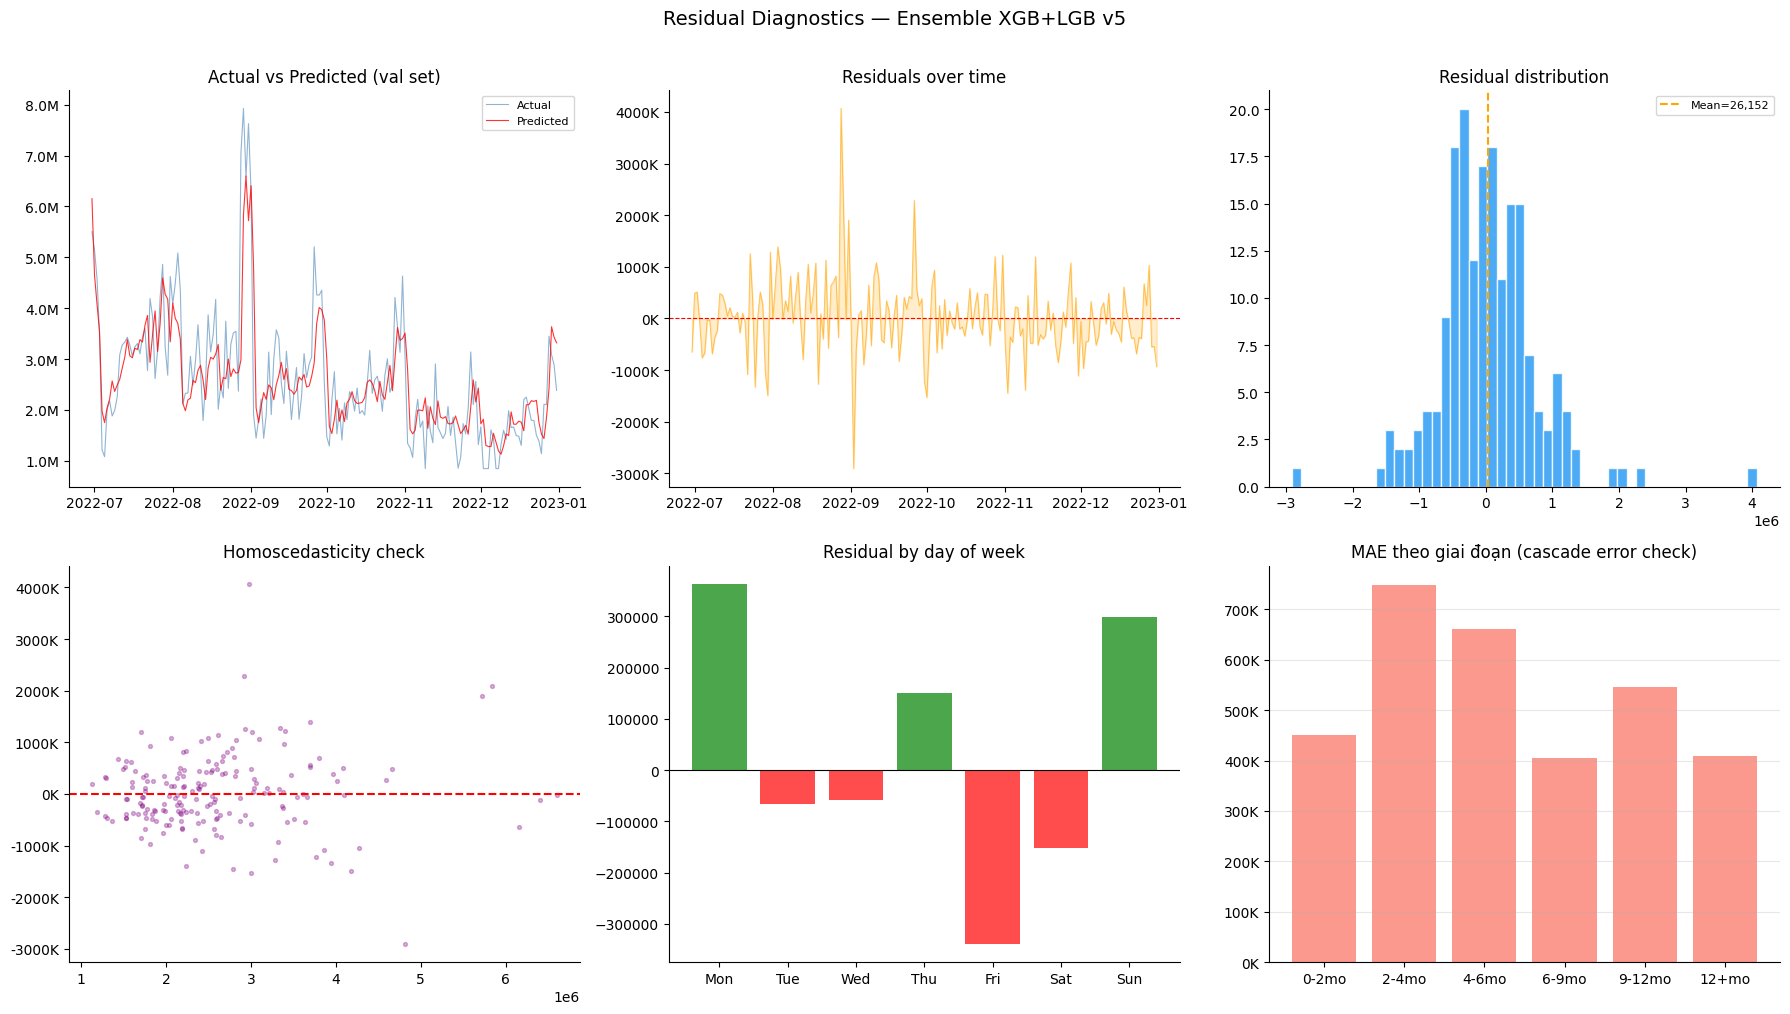


CELL 13 — RETRAIN ON FULL DATA
Retrain trên 3,454 rows
Range: 2012-07-04 → 2022-12-31
[✓] xgb_full trained
[✓] lgb_full trained
[✓] revenue_buffer_full: 3,833 ngày
    Đến: 2022-12-31
[✓] Models + meta saved to models/
Sample submission shape: (548, 3)

Submission dates: 548 ngày
Từ 2023-01-01 → 2024-07-01
Cần forecast: 548 ngày

Forecasting 548 ngày recursively...
  [100/548] 2023-04-10 → 4,262,871 (CI: 3,623,441-4,902,302)
  [200/548] 2023-07-19 → 3,490,894 (CI: 2,967,260-4,014,528)
  [300/548] 2023-10-27 → 3,729,137 (CI: 3,169,767-4,288,508)
  [400/548] 2024-02-04 → 2,808,776 (CI: 2,387,460-3,230,092)
  [500/548] 2024-05-14 → 5,767,173 (CI: 4,902,097-6,632,249)

Hoàn thành 548 predictions ✓
COGS monthly ratios computed ✓

[✓] Xuất submission.csv (548 rows)
      Date      Revenue         COGS  revenue_upper  revenue_lower
2023-01-01 2,011,851.59 1,633,315.03   2,313,629.33   1,710,073.85
2023-01-02 2,036,915.76 1,653,663.30   2,342,453.12   1,731,378.40
2023-01-03 1,564,117.69 1,26

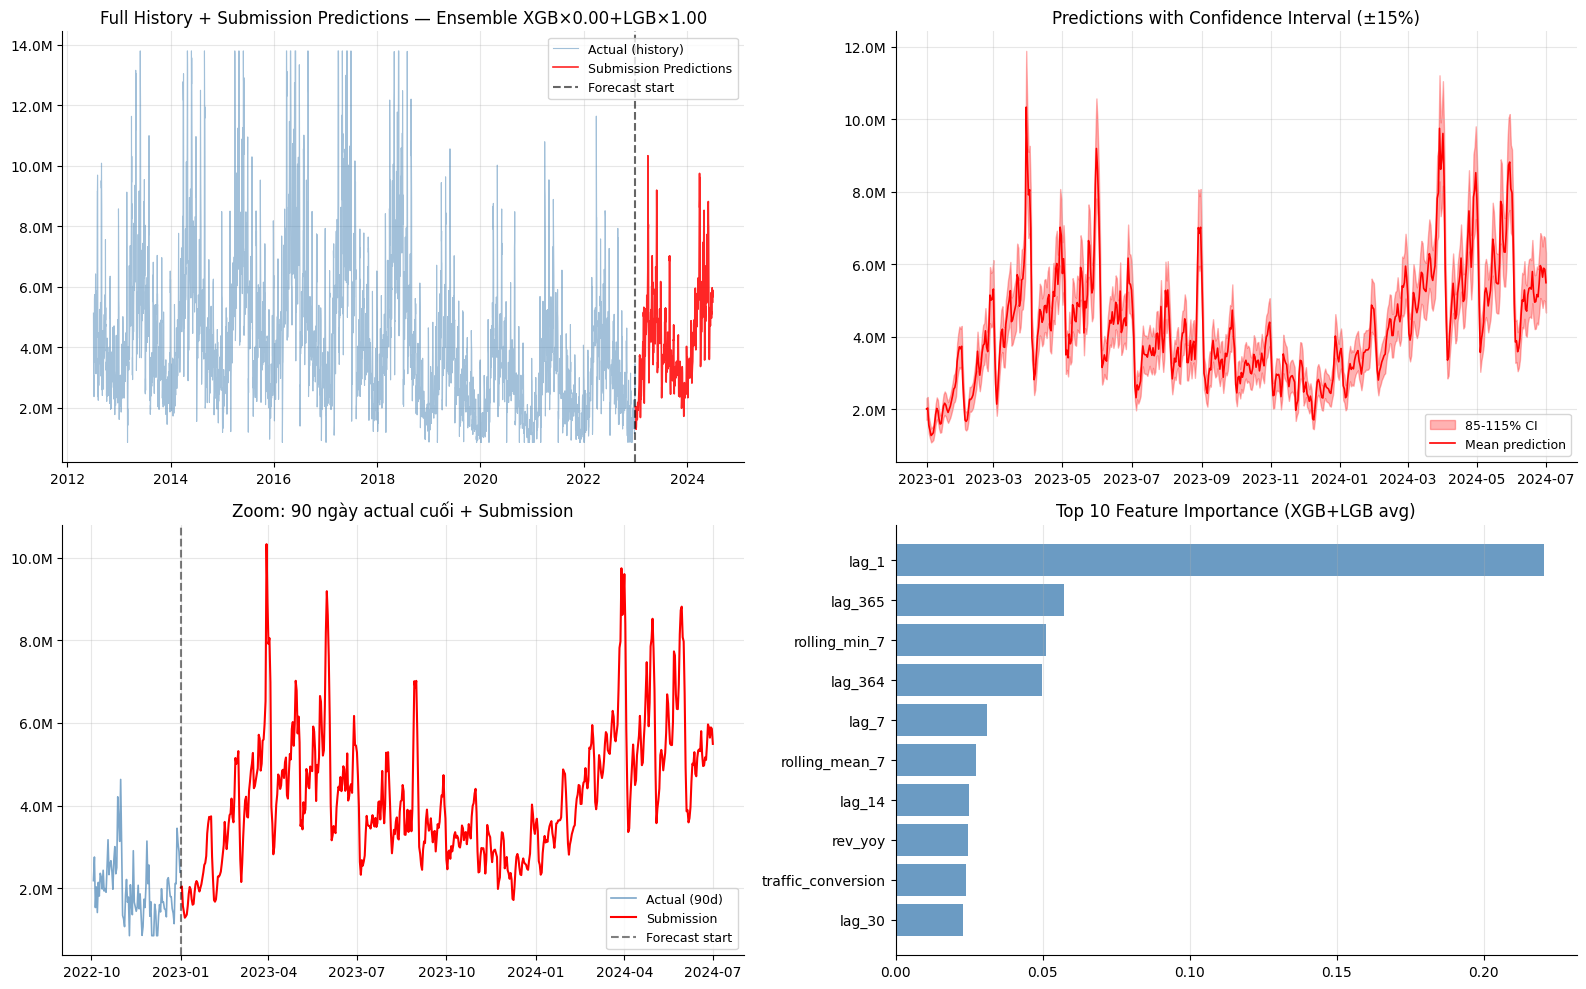


PIPELINE HOÀN TẤT — v5 ENHANCED
Val R²   : 0.6448
Val MAE  : 537,530
Val RMSE : 745,522
Val MAPE : 23.95%
Features : 41
Submission: submission.csv (548 rows)
✅ Includes: holiday proximity + trend×seasonality + confidence intervals


In [ ]:
# ============================================================
# REVENUE FORECASTING v5 — ENHANCED PIPELINE (FIXED)
#
# Fix: lỗi AttributeError: 'float' object has no attribute 'clip'
# ============================================================


# ============================================================
# CELL 1 — INSTALL & DOWNLOAD
# ============================================================
!pip install -q optuna lightgbm xgboost shap joblib scipy gdown
!gdown --folder https://drive.google.com/drive/folders/10d9h-nkQccHtRzF7LNYCpVJJbTKYLJZd


# ============================================================
# CELL 2 — IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import json
import os

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar
from xgboost import XGBRegressor
import lightgbm as lgb
import optuna
import joblib

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RANDOM_SEED = 42
DATA_PATH   = 'Data'
np.random.seed(RANDOM_SEED)
print('Libraries loaded ✓')


# ============================================================
# CELL 3 — LOAD & PREPROCESS
# ============================================================
products    = pd.read_csv(f'{DATA_PATH}/products.csv')
customers   = pd.read_csv(f'{DATA_PATH}/customers.csv')
promotions  = pd.read_csv(f'{DATA_PATH}/promotions.csv')
geography   = pd.read_csv(f'{DATA_PATH}/geography.csv')
orders      = pd.read_csv(f'{DATA_PATH}/orders.csv')
order_items = pd.read_csv(f'{DATA_PATH}/order_items.csv', low_memory=False)
payments    = pd.read_csv(f'{DATA_PATH}/payments.csv')
shipments   = pd.read_csv(f'{DATA_PATH}/shipments.csv')
returns     = pd.read_csv(f'{DATA_PATH}/returns.csv')
reviews     = pd.read_csv(f'{DATA_PATH}/reviews.csv')
sales       = pd.read_csv(f'{DATA_PATH}/sales.csv')
inventory   = pd.read_csv(f'{DATA_PATH}/inventory.csv')
web_traffic = pd.read_csv(f'{DATA_PATH}/web_traffic.csv')


def parse_dates(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

parse_dates(orders,      ['order_date'])
parse_dates(customers,   ['signup_date'])
parse_dates(shipments,   ['ship_date', 'delivery_date'])
parse_dates(returns,     ['return_date'])
parse_dates(reviews,     ['review_date'])
parse_dates(sales,       ['Date'])
parse_dates(web_traffic, ['date'])
parse_dates(inventory,   ['snapshot_date'])
parse_dates(promotions,  ['start_date', 'end_date'])

returns['refund_amount']         = returns['refund_amount'].fillna(0)
payments['payment_value']        = payments['payment_value'].fillna(0)
customers['age_group']           = customers['age_group'].fillna('unknown')
customers['acquisition_channel'] = customers['acquisition_channel'].fillna('unknown')

order_items['has_promo']      = (order_items['promo_id'].notnull() | order_items['promo_id_2'].notnull()).astype(int)
order_items['total_discount'] = order_items['discount_amount']
order_items = order_items[(order_items['unit_price'] > 0) & (order_items['quantity'] > 0)]
returns     = returns[returns['refund_amount'] >= 0]

def clean_text(x):
    return x.strip().lower() if isinstance(x, str) else x

products['category'] = products['category'].apply(clean_text)
products['segment']  = products['segment'].apply(clean_text)
customers['city']    = customers['city'].apply(clean_text)

order_items['line_total'] = order_items['quantity'] * order_items['unit_price']
order_items['revenue']    = order_items['line_total']
low_oi, up_oi = order_items['revenue'].quantile([0.01, 0.99])
order_items   = order_items[(order_items['revenue'] >= low_oi) & (order_items['revenue'] <= up_oi)]

print('Preprocessing done ✓')
print(f'Sales range: {sales["Date"].min().date()} → {sales["Date"].max().date()}')


# ============================================================
# CELL 4 — FEATURE ENGINEERING
# ============================================================
df = sales.copy()
df = df.sort_values('Date').reset_index(drop=True)

# Clip Revenue outliers trước khi tạo feature
low_r, up_r = df['Revenue'].quantile([0.01, 0.99])
df['Revenue'] = df['Revenue'].clip(low_r, up_r)


def add_time_features(df):
    df = df.copy()
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['month']       = df['Date'].dt.month
    df['year']        = df['Date'].dt.year
    df['quarter']     = df['Date'].dt.quarter
    df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
    df['month_day']   = df['Date'].dt.strftime('%m-%d')

    doy = df['Date'].dt.dayofyear
    dow = df['Date'].dt.dayofweek

    for k in [1, 2]:
        df[f'sin_week_{k}'] = np.sin(2 * np.pi * k * dow / 7)
        df[f'cos_week_{k}'] = np.cos(2 * np.pi * k * dow / 7)

    for k in [1, 2, 3]:
        df[f'sin_year_{k}'] = np.sin(2 * np.pi * k * doy / 365.25)
        df[f'cos_year_{k}'] = np.cos(2 * np.pi * k * doy / 365.25)

    df['sin_biannual'] = np.sin(4 * np.pi * doy / 365)
    df['cos_biannual'] = np.cos(4 * np.pi * doy / 365)
    df['sin_quarter']  = np.sin(2 * np.pi * df['quarter'] / 4)
    df['cos_quarter']  = np.cos(2 * np.pi * df['quarter'] / 4)

    min_date      = df['Date'].min()
    df['trend']    = (df['Date'] - min_date).dt.days
    df['trend_sq'] = df['trend'] ** 2

    return df, min_date


def add_lag_rolling(df):
    df    = df.copy()
    rev   = df['Revenue']
    rev_s = rev.shift(1)

    df['lag_1']   = rev.shift(1)
    df['lag_7']   = rev.shift(7)
    df['lag_14']  = rev.shift(14)
    df['lag_30']  = rev.shift(30)
    df['lag_365'] = rev.shift(365)
    df['lag_364'] = rev.shift(364)

    df['rolling_mean_7']  = rev_s.rolling(7,  min_periods=7).mean()
    df['rolling_mean_14'] = rev_s.rolling(14, min_periods=14).mean()
    df['rolling_mean_30'] = rev_s.rolling(30, min_periods=30).mean()
    df['rolling_std_7']   = rev_s.rolling(7,  min_periods=7).std()
    df['rolling_std_30']  = rev_s.rolling(30, min_periods=30).std()
    df['rolling_max_7']   = rev_s.rolling(7,  min_periods=1).max()
    df['rolling_min_7']   = rev_s.rolling(7,  min_periods=1).min()

    df['rolling_mean_7_ly']  = rev.shift(365).rolling(7,  min_periods=4).mean()
    df['rolling_mean_30_ly'] = rev.shift(365).rolling(30, min_periods=15).mean()

    df['trend_7_30']  = df['rolling_mean_7']  - df['rolling_mean_30']
    df['trend_14_30'] = df['rolling_mean_14'] - df['rolling_mean_30']
    df['range_ratio_7'] = (
        (df['rolling_max_7'] - df['rolling_min_7'])
        / df['rolling_mean_7'].clip(lower=1)
    ).fillna(0)

    df['pct_change_7']  = rev_s.pct_change(7).clip(-2, 2)
    df['pct_change_30'] = rev_s.pct_change(30).clip(-2, 2)
    df['rev_yoy']       = (rev_s / rev.shift(366) - 1).clip(-2, 2)
    df['rev_volatility_30'] = (df['rolling_std_30'] / df['rolling_mean_30'].clip(lower=1)).fillna(0)

    df['post_break']        = (df['Date'] >= '2019-01-01').astype(int)
    df['post_covid']        = (df['Date'] >= '2020-03-01').astype(int)
    df['post_break_x_lag1'] = df['post_break'] * df['lag_1']

    return df


def add_traffic_features(df, traffic_df):
    traffic = traffic_df.copy().rename(columns={'date': 'Date'})
    traffic['Date'] = pd.to_datetime(traffic['Date'])

    if traffic.groupby('Date').size().max() > 1:
        print('[FIX] web_traffic có nhiều row/ngày — aggregate')
        traffic = traffic.groupby('Date').first().reset_index()

    df = df.merge(traffic, on='Date', how='left')

    traffic_cols = ['sessions', 'unique_visitors', 'page_views',
                    'bounce_rate', 'avg_session_duration_sec']
    for col in traffic_cols:
        if col in df.columns:
            missing_before = df[col].isna().sum()
            df[col] = df[col].fillna(df[col].shift(1).rolling(7, min_periods=1).median())
            df[col] = df[col].ffill()
            df[col] = df[col].fillna(df[col].median())
            print(f'[FILL] {col}: {missing_before} NaN → {df[col].isna().sum()} NaN')

    if 'traffic_source' in df.columns:
        df['traffic_source'] = df['traffic_source'].fillna('unknown')
    else:
        df['traffic_source'] = 'unknown'
    df = pd.get_dummies(df, columns=['traffic_source'], drop_first=False)

    df['sessions_lag_1']      = df['sessions'].shift(1)
    df['sessions_lag_7']      = df['sessions'].shift(7)
    df['sessions_growth']     = df['sessions'].shift(1) - df['sessions'].shift(2)
    df['views_per_session']   = (df['page_views'] / df['sessions'].clip(lower=1)).replace([np.inf, -np.inf], 0)
    df['is_engaged']          = (df['views_per_session'] > 1).astype(int)
    df['traffic_conversion']  = (df['Revenue'].shift(1) / df['sessions'].shift(1).clip(lower=1)).fillna(0)

    return df


def add_promo_features(df, promo_df):
    promo = promo_df.copy()
    promo_expanded = (
        promo.apply(lambda r: pd.date_range(r['start_date'], r['end_date']), axis=1)
        .explode().reset_index()
        .rename(columns={0: 'Date', 'index': 'promo_idx'})
        .merge(promo[['discount_value']], left_on='promo_idx', right_index=True)
    )
    promo_daily = promo_expanded.groupby('Date').agg(
        num_active_promos=('discount_value', 'count'),
        total_discount   =('discount_value', 'sum'),
        avg_discount     =('discount_value', 'mean'),
        max_discount     =('discount_value', 'max')
    ).reset_index()
    promo_daily['is_promo_day'] = 1

    df = df.merge(promo_daily, on='Date', how='left')
    promo_cols = ['num_active_promos', 'total_discount', 'avg_discount', 'max_discount', 'is_promo_day']
    df[promo_cols] = df[promo_cols].fillna(0)

    df['promo_lag_1'] = df['is_promo_day'].shift(1).fillna(0)
    df['promo_lag_7'] = df['is_promo_day'].shift(7).fillna(0)

    df['promo_intensity'] = df['num_active_promos'] * df['avg_discount']
    if 'sessions' in df.columns:
        df['promo_intensity'] *= df['sessions']
    q99 = df['promo_intensity'].quantile(0.99).clip(1)
    df['promo_intensity'] = (df['promo_intensity'] / q99).clip(0, 1)

    if 'is_weekend' in df.columns:
        df['promo_x_weekend'] = df['is_promo_day'] * df['is_weekend']
    df['post_break_x_promo'] = df['post_break'] * df['is_promo_day']

    return df


TET_DATES = {
    2012: '2012-01-23', 2013: '2013-02-10', 2014: '2014-01-31',
    2015: '2015-02-19', 2016: '2016-02-08', 2017: '2017-01-28',
    2018: '2018-02-16', 2019: '2019-02-05', 2020: '2020-01-25',
    2021: '2021-02-12', 2022: '2022-02-01', 2023: '2023-01-22',
    2024: '2024-02-10', 2025: '2025-01-29',
}
FIXED_HOLIDAYS = ['02-14', '03-08', '10-20', '12-24', '04-30', '05-01', '09-02', '12-31', '01-01']

_tet_days   = pd.to_datetime(list(TET_DATES.values()))
_tet_ranges = []
for d in _tet_days:
    _tet_ranges.extend(pd.date_range(d - pd.Timedelta(days=3), d + pd.Timedelta(days=3)))
_tet_ranges = pd.to_datetime(_tet_ranges)


def days_to_fixed(date):
    diffs = []
    for y in range(date.year - 1, date.year + 2):
        for h in FIXED_HOLIDAYS:
            try:
                d    = pd.to_datetime(f'{y}-{h}')
                diff = (d - date).days
                if 0 <= diff <= 60:
                    diffs.append(diff)
            except Exception:
                pass
    return min(diffs) if diffs else 999


def add_holiday_features(df):
    df = df.copy()
    df['is_tet']     = df['Date'].isin(_tet_ranges).astype(int)
    df['days_to_tet'] = df['Date'].apply(
        lambda x: min([(t - x).days for t in _tet_days if (t - x).days >= 0] or [999])
    )
    df['is_near_tet']   = (df['days_to_tet'] <= 7).astype(int)
    df['is_medium_tet'] = ((df['days_to_tet'] > 7) & (df['days_to_tet'] <= 30)).astype(int)

    df['tet_decay'] = np.exp(-df['days_to_tet'] / 14).clip(0, 1)

    df['month_day']               = df['Date'].dt.strftime('%m-%d')
    df['is_fixed_holiday']        = df['month_day'].isin(FIXED_HOLIDAYS).astype(int)
    df['days_to_fixed_holiday']   = df['Date'].apply(days_to_fixed)

    df['fixed_holiday_decay'] = np.exp(-df['days_to_fixed_holiday'] / 7).clip(0, 1)

    df['holiday_proximity_tet'] = np.exp(-df['days_to_tet'] / 3).clip(0, 1)
    df['holiday_proximity_fixed'] = np.exp(-df['days_to_fixed_holiday'] / 3).clip(0, 1)
    df['is_holiday_week'] = ((df['days_to_tet'] <= 7) | (df['days_to_fixed_holiday'] <= 7)).astype(int)

    if 'is_promo_day' in df.columns:
        df['near_tet_promo']    = (df['days_to_tet'] <= 14).astype(int) * df['is_promo_day']
        df['promo_x_tet']       = df['is_promo_day'] * df['is_near_tet']
        df['promo_x_holiday']   = df['is_promo_day'] * df['is_fixed_holiday']

    return df


def add_inventory_features(df, inv_df):
    inv = inv_df.copy()
    inv['snapshot_date'] = pd.to_datetime(inv['snapshot_date'])
    inv_agg = inv.groupby('snapshot_date')[['stockout_days', 'days_of_supply', 'fill_rate']].mean().reset_index()

    inv_agg['year_month'] = (inv_agg['snapshot_date'] + pd.DateOffset(months=1)).dt.to_period('M')
    inv_monthly = inv_agg.groupby('year_month')[['stockout_days', 'days_of_supply', 'fill_rate']].mean().reset_index()

    df['year_month'] = df['Date'].dt.to_period('M')
    df = df.merge(inv_monthly, on='year_month', how='left')

    for col in ['stockout_days', 'days_of_supply', 'fill_rate']:
        if col in df.columns:
            df[col] = df[col].ffill().fillna(df[col].median())

    return df


df, MIN_DATE = add_time_features(df)
df = add_lag_rolling(df)
df = add_traffic_features(df, web_traffic)
df = add_promo_features(df, promotions)
df = add_holiday_features(df)
df = add_inventory_features(df, inventory)
df = df.sort_values('Date').reset_index(drop=True)

print('\nAll features built ✓')
print(f'Shape: {df.shape}')
print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')

FEATURE_GROUPS = {
    'time':       ['day_of_week', 'month', 'year', 'quarter', 'is_weekend'],
    'fourier':    ['sin_week_1', 'cos_week_1', 'sin_week_2', 'cos_week_2',
                   'sin_year_1', 'cos_year_1', 'sin_year_2', 'cos_year_2', 'sin_year_3', 'cos_year_3',
                   'sin_biannual', 'cos_biannual', 'sin_quarter', 'cos_quarter'],
    'trend':      ['trend', 'trend_sq'],
    'trend_interaction': ['trend_x_month', 'trend_x_quarter'],
    'lag':        ['lag_1', 'lag_7', 'lag_14', 'lag_30',
                   'lag_365', 'lag_364',
                   'rolling_mean_7_ly', 'rolling_mean_30_ly'],
    'rolling':    ['rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30',
                   'rolling_std_7', 'rolling_std_30',
                   'rolling_max_7', 'rolling_min_7',
                   'trend_7_30', 'trend_14_30', 'range_ratio_7'],
    'momentum':   ['pct_change_7', 'pct_change_30', 'rev_yoy', 'rev_volatility_30'],
    'traffic':    ['sessions', 'unique_visitors', 'page_views',
                   'bounce_rate', 'avg_session_duration_sec',
                   'sessions_lag_1', 'sessions_lag_7', 'sessions_growth',
                   'views_per_session', 'is_engaged', 'traffic_conversion'],
    'promo':      ['is_promo_day', 'num_active_promos', 'total_discount',
                   'avg_discount', 'max_discount',
                   'promo_lag_1', 'promo_lag_7', 'promo_intensity',
                   'promo_x_weekend', 'near_tet_promo', 'promo_x_tet', 'promo_x_holiday',
                   'post_break_x_promo'],
    'holiday':    ['is_tet', 'days_to_tet', 'is_near_tet', 'is_medium_tet',
                   'tet_decay', 'is_fixed_holiday', 'days_to_fixed_holiday',
                   'fixed_holiday_decay',
                   'holiday_proximity_tet', 'holiday_proximity_fixed', 'is_holiday_week'],
    'structural': ['post_break', 'post_covid', 'post_break_x_lag1'],
    'inventory':  ['stockout_days', 'days_of_supply', 'fill_rate'],
}

ts_dummies = [c for c in df.columns if c.startswith('traffic_source_')]
FEATURE_GROUPS['traffic'] += ts_dummies

ALL_CANDIDATE_FEATURES = [f for group in FEATURE_GROUPS.values() for f in group]
ALL_CANDIDATE_FEATURES = list(dict.fromkeys(ALL_CANDIDATE_FEATURES))
ALL_CANDIDATE_FEATURES = [f for f in ALL_CANDIDATE_FEATURES if f in df.columns]

df['trend_x_month'] = df['trend'] * df['month'] / 1000
df['trend_x_quarter'] = df['trend'] * df['quarter'] / 1000
ALL_CANDIDATE_FEATURES.extend(['trend_x_month', 'trend_x_quarter'])

print(f'\nTotal candidate features: {len(ALL_CANDIDATE_FEATURES)}')
for group, feats in FEATURE_GROUPS.items():
    available = [f for f in feats if f in df.columns]
    print(f'  {group:20s}: {len(available):2d}')


# ============================================================
# CELL 5 — TRAIN/VAL SPLIT
# ============================================================
df = df.sort_values('Date').reset_index(drop=True)

total_days      = len(df)
cutoff_21_idx   = int(total_days * (2 / 3))
cutoff_21       = df.iloc[cutoff_21_idx]['Date']
cutoff_6m       = df['Date'].max() - pd.DateOffset(months=6)
CUTOFF          = max(cutoff_21, cutoff_6m)

print(f'Cutoff 2:1 dynamic  : {cutoff_21.date()}')
print(f'Cutoff 6m from end  : {cutoff_6m.date()}')
print(f'Cutoff sử dụng      : {CUTOFF.date()}')

df_model = df.drop(columns=['year_month', 'month_day'], errors='ignore')

train_df = df_model[df_model['Date'] <  CUTOFF][ALL_CANDIDATE_FEATURES + ['Revenue', 'Date']].dropna()
val_df   = df_model[df_model['Date'] >= CUTOFF][ALL_CANDIDATE_FEATURES + ['Revenue', 'Date']].dropna()

X_train, y_train = train_df[ALL_CANDIDATE_FEATURES], train_df['Revenue']
X_val,   y_val   = val_df[ALL_CANDIDATE_FEATURES],   val_df['Revenue']

ratio = len(train_df) / len(val_df)
print(f'\nTrain: {len(X_train):,} rows | {train_df["Date"].min().date()} → {train_df["Date"].max().date()}')
print(f'Val  : {len(X_val):,} rows | {val_df["Date"].min().date()} → {val_df["Date"].max().date()}')
print(f'Ratio Train/Val: {ratio:.2f}')


# ============================================================
# CELL 6 — FEATURE SELECTION
# ============================================================
print('\n[Feature Selection] Running MI + RF importance union...')

train_fs = train_df[ALL_CANDIDATE_FEATURES + ['Revenue']].dropna()
X_fs     = train_fs[ALL_CANDIDATE_FEATURES]
y_fs     = train_fs['Revenue']

mi_scores = mutual_info_regression(X_fs, y_fs, random_state=RANDOM_SEED)
mi_series = pd.Series(mi_scores, index=ALL_CANDIDATE_FEATURES).sort_values(ascending=False)
print('\n[MI] Top 20:')
print(mi_series.head(20).to_string())

rf_sel = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=5,
                                random_state=RANDOM_SEED, n_jobs=-1)
rf_sel.fit(X_fs, y_fs)
rf_imp = pd.Series(rf_sel.feature_importances_, index=ALL_CANDIDATE_FEATURES).sort_values(ascending=False)
print('\n[RF] Top 20:')
print(rf_imp.head(20).to_string())

TOP_N   = 25
top_mi  = set(mi_series.head(TOP_N).index)
top_rf  = set(rf_imp.head(TOP_N).index)
selected = list(top_mi | top_rf)

MUST_HAVE = [
    'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_365', 'lag_364',
    'rolling_mean_7_ly', 'rolling_mean_30_ly',
    'rolling_mean_7', 'rolling_mean_30',
    'trend', 'trend_sq', 'trend_x_month', 'trend_x_quarter',
    'sin_year_1', 'cos_year_1', 'sin_week_1', 'cos_week_1',
    'post_break', 'post_covid', 'pct_change_7', 'rev_yoy',
]
for f in MUST_HAVE:
    if f in ALL_CANDIDATE_FEATURES and f not in selected:
        selected.append(f)
        print(f'[FORCED] Thêm must-have: {f}')

CORE_FEATURES = [f for f in selected if f in df_model.columns]
print(f'\n[Feature Selection] Chọn {len(CORE_FEATURES)} features')

X_train = X_train[CORE_FEATURES]
X_val   = X_val[CORE_FEATURES]


# ============================================================
# CELL 7 — METRICS HELPERS
# ============================================================
def evaluate_metrics(y_true, y_pred, name='Model'):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true.clip(lower=1))) * 100
    print(f'\n{"="*50}\n  {name}\n{"="*50}')
    print(f'  R²   : {r2:.4f}')
    print(f'  MAE  : {mae:,.0f}')
    print(f'  RMSE : {rmse:,.0f}')
    print(f'  MAPE : {mape:.2f}%')
    return {'model': name, 'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


# ============================================================
# CELL 8 — OPTUNA TUNING: XGBoost
# ============================================================
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'n_jobs': -1, 'random_state': RANDOM_SEED, 'verbosity': 0,
    }
    tscv  = TimeSeriesSplit(n_splits=5, gap=7)
    rmses = []
    for step, (tr_idx, va_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        m = XGBRegressor(**params)
        m.fit(X_tr, y_tr)
        rmses.append(np.sqrt(mean_squared_error(y_va, m.predict(X_va))))
        trial.report(np.mean(rmses), step=step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(rmses)

xgb_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
xgb_study.optimize(xgb_objective, n_trials=80, show_progress_bar=True)

XGB_BEST_PARAMS = {**xgb_study.best_params, 'n_jobs': -1,
                   'random_state': RANDOM_SEED, 'verbosity': 0}
print(f'\nBest XGB CV RMSE: {xgb_study.best_value:,.0f}')
print(f'Best params: {xgb_study.best_params}')


# ============================================================
# CELL 9 — OPTUNA TUNING: LightGBM
# ============================================================
def lgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'max_depth':         trial.suggest_int('max_depth', 3, 9),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'n_jobs': -1, 'verbose': -1, 'random_state': RANDOM_SEED,
    }
    tscv  = TimeSeriesSplit(n_splits=5, gap=7)
    rmses = []
    for step, (tr_idx, va_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        m = lgb.LGBMRegressor(**params)
        m.fit(X_tr, y_tr)
        rmses.append(np.sqrt(mean_squared_error(y_va, m.predict(X_va))))
        trial.report(np.mean(rmses), step=step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(rmses)

lgb_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
lgb_study.optimize(lgb_objective, n_trials=60, show_progress_bar=True)

LGB_BEST_PARAMS = {**lgb_study.best_params, 'n_jobs': -1,
                   'verbose': -1, 'random_state': RANDOM_SEED}
print(f'\nBest LGB CV RMSE: {lgb_study.best_value:,.0f}')
print(f'Best params: {lgb_study.best_params}')


# ============================================================
# CELL 10 — TRAIN FINAL MODELS
# ============================================================
print('\nTraining final models on train set...')

xgb_model = XGBRegressor(**XGB_BEST_PARAMS)
xgb_model.fit(X_train, y_train)

lgb_model = lgb.LGBMRegressor(**LGB_BEST_PARAMS)
lgb_model.fit(X_train, y_train)

xgb_pred_val = xgb_model.predict(X_val)
lgb_pred_val = lgb_model.predict(X_val)

xgb_metrics = evaluate_metrics(y_val, xgb_pred_val, 'XGBoost (tuned)')
lgb_metrics  = evaluate_metrics(y_val, lgb_pred_val, 'LightGBM (tuned)')

fi_xgb      = pd.Series(xgb_model.feature_importances_, index=CORE_FEATURES)
fi_lgb      = pd.Series(lgb_model.feature_importances_, index=CORE_FEATURES)
fi_xgb_norm = fi_xgb / fi_xgb.sum()
fi_lgb_norm = fi_lgb / fi_lgb.sum()
fi_avg      = ((fi_xgb_norm + fi_lgb_norm) / 2).sort_values(ascending=False)

print('\nTop 15 features (avg XGB+LGB):')
print(fi_avg.head(15).to_string())


# ============================================================
# CELL 11 — ENSEMBLE WEIGHT
# ============================================================
WEIGHT_CUTOFF   = CUTOFF - pd.DateOffset(months=3)
weight_df       = train_df[train_df['Date'] >= WEIGHT_CUTOFF]
X_weight        = weight_df[CORE_FEATURES]
y_weight        = weight_df['Revenue']
pred_xgb_w      = xgb_model.predict(X_weight)
pred_lgb_w      = lgb_model.predict(X_weight)

def ensemble_rmse(w):
    pred = w * pred_xgb_w + (1 - w) * pred_lgb_w
    return np.sqrt(mean_squared_error(y_weight, pred))

result_w = minimize_scalar(ensemble_rmse, bounds=(0, 1), method='bounded')
BEST_W   = result_w.x
print(f'\nEnsemble weight (tối ưu trên train recent 3 tháng):')
print(f'  XGB weight: {BEST_W:.3f}  |  LGB weight: {1-BEST_W:.3f}')

ensemble_pred_val = BEST_W * xgb_pred_val + (1 - BEST_W) * lgb_pred_val
ens_metrics       = evaluate_metrics(y_val, ensemble_pred_val, f'Ensemble XGB×{BEST_W:.2f}+LGB×{1-BEST_W:.2f}')


# ============================================================
# CELL 12 — RESIDUAL DIAGNOSTICS
# ============================================================
residuals  = y_val.values - ensemble_pred_val
dates_val  = val_df['Date'].values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].plot(dates_val, y_val.values,       alpha=0.6, label='Actual',    linewidth=0.8, color='steelblue')
axes[0, 0].plot(dates_val, ensemble_pred_val,  alpha=0.8, label='Predicted', linewidth=0.8, color='red')
axes[0, 0].set_title('Actual vs Predicted (val set)')
axes[0, 0].legend(fontsize=8)
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

axes[0, 1].plot(dates_val, residuals, alpha=0.6, linewidth=0.7, color='orange')
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0, 1].fill_between(dates_val, residuals, 0, alpha=0.2, color='orange')
axes[0, 1].set_title('Residuals over time')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

axes[0, 2].hist(residuals, bins=50, edgecolor='white', color='#2196F3', alpha=0.8)
axes[0, 2].axvline(residuals.mean(), color='orange', linestyle='--', label=f'Mean={residuals.mean():,.0f}')
axes[0, 2].set_title('Residual distribution')
axes[0, 2].legend(fontsize=8)

axes[1, 0].scatter(ensemble_pred_val, residuals, alpha=0.3, s=8, color='purple')
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title('Homoscedasticity check')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

dow_mean = pd.DataFrame({'dow': pd.to_datetime(dates_val).dayofweek, 'res': residuals}).groupby('dow')['res'].mean()
axes[1, 1].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], dow_mean.values,
               color=['red' if v < 0 else 'green' for v in dow_mean.values], alpha=0.7)
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].set_title('Residual by day of week')

val_df_plot    = val_df.copy().reset_index(drop=True)
val_df_plot['abs_error'] = np.abs(y_val.values - ensemble_pred_val)
val_df_plot['days_from_start'] = (val_df_plot['Date'] - val_df_plot['Date'].min()).dt.days
val_df_plot['period'] = pd.cut(val_df_plot['days_from_start'], bins=6,
                                labels=['0-2mo','2-4mo','4-6mo','6-9mo','9-12mo','12+mo'])
period_error = val_df_plot.groupby('period', observed=True)['abs_error'].mean()
axes[1, 2].bar(period_error.index, period_error.values, color='salmon', alpha=0.8)
axes[1, 2].set_title('MAE theo giai đoạn (cascade error check)')
axes[1, 2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Residual Diagnostics — Ensemble XGB+LGB v5', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


# ============================================================
# CELL 13 — RETRAIN TRÊN TOÀN BỘ DATA
# ============================================================
print('\n' + '='*60)
print('CELL 13 — RETRAIN ON FULL DATA')
print('='*60)

df_full_model = df_model.drop(columns=['year_month', 'month_day'], errors='ignore')
full_m        = df_full_model[CORE_FEATURES + ['Revenue']].dropna()
X_full        = full_m[CORE_FEATURES]
y_full        = full_m['Revenue']

print(f'Retrain trên {len(X_full):,} rows')
print(f'Range: {df_full_model["Date"].min().date()} → {df_full_model["Date"].max().date()}')

xgb_full = XGBRegressor(**XGB_BEST_PARAMS)
xgb_full.fit(X_full, y_full)
print(f'[✓] xgb_full trained')

lgb_full = lgb.LGBMRegressor(**LGB_BEST_PARAMS)
lgb_full.fit(X_full, y_full)
print(f'[✓] lgb_full trained')

revenue_buffer_full = (
    df_full_model.dropna(subset=['Revenue'])
    .set_index('Date')['Revenue']
    .to_dict()
)
print(f'[✓] revenue_buffer_full: {len(revenue_buffer_full):,} ngày')
print(f'    Đến: {max(revenue_buffer_full.keys()).date()}')

os.makedirs('models', exist_ok=True)
joblib.dump(xgb_full, 'models/xgb_full.pkl')
joblib.dump(lgb_full, 'models/lgb_full.pkl')

model_meta = {
    'features':   CORE_FEATURES,
    'xgb_weight': float(BEST_W),
    'lgb_weight': float(1 - BEST_W),
    'val_rmse':   float(ens_metrics['RMSE']),
    'val_r2':     float(ens_metrics['R2']),
    'val_mape':   float(ens_metrics['MAPE']),
    'cutoff':     str(CUTOFF.date()),
    'n_features': len(CORE_FEATURES),
    'min_date':   str(MIN_DATE.date()),
}
with open('models/model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)
print('[✓] Models + meta saved to models/')


# ============================================================
# CELL 14 — RECURSIVE FORECAST HELPERS
# ============================================================
def get_lag(buffer, date, lag_days):
    return buffer.get(date - pd.Timedelta(days=lag_days), np.nan)

def get_rolling(buffer, date, window, func='mean'):
    dates  = pd.date_range(end=date - pd.Timedelta(days=1), periods=window, freq='D')
    values = [v for d in dates if (v := buffer.get(d)) is not None and not np.isnan(v)]
    if not values:
        return np.nan if func == 'mean' else 0.0
    if func == 'mean':  return np.mean(values)
    if func == 'std':   return np.std(values) if len(values) > 1 else 0.0
    if func == 'max':   return np.max(values)
    if func == 'min':   return np.min(values)

def get_lag_year_rolling(buffer, date, lag_days, window, func='mean'):
    anchor = date - pd.Timedelta(days=lag_days)
    dates  = pd.date_range(end=anchor, periods=window, freq='D')
    values = [v for d in dates if (v := buffer.get(d)) is not None and not np.isnan(v)]
    if not values:
        return np.nan
    return np.mean(values) if func == 'mean' else np.std(values)

web_hist = web_traffic.copy()
web_hist['Date'] = pd.to_datetime(web_hist['date'])
web_hist = web_hist.drop(columns=['date']).set_index('Date')
TRAFFIC_COLS = ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec']
traffic_medians = {col: web_hist[col].median() if col in web_hist.columns else 0
                   for col in TRAFFIC_COLS}

def get_web_smart(date, col, fallback_median):
    try:
        cand = date.replace(year=date.year - 1)
        if date.month == 2 and date.day == 29:
            cand = date.replace(year=date.year - 1, day=28)
    except Exception:
        cand = None
    if cand is not None and cand in web_hist.index and col in web_hist.columns:
        return web_hist.loc[cand, col]
    if col in web_hist.columns:
        mask = (web_hist.index.month == date.month) & (web_hist.index.dayofweek == date.dayofweek)
        if mask.any():
            return web_hist.loc[mask, col].median()
    return fallback_median


# ============================================================
# CELL 15 — GENERATE SUBMISSION
# ============================================================
sample_sub = pd.read_csv(f'{DATA_PATH}/sample_submission.csv')
print('Sample submission shape:', sample_sub.shape)

date_col       = [c for c in sample_sub.columns if 'date' in c.lower() or 'Date' in c][0]
sample_sub[date_col] = pd.to_datetime(sample_sub[date_col])
sample_sub     = sample_sub.sort_values(date_col).reset_index(drop=True)
submission_dates = sample_sub[date_col].tolist()

print(f'\nSubmission dates: {len(submission_dates)} ngày')
print(f'Từ {submission_dates[0].date()} → {submission_dates[-1].date()}')

buffer_max    = max(revenue_buffer_full.keys())
not_in_buffer = [d for d in submission_dates if d not in revenue_buffer_full]
print(f'Cần forecast: {len(not_in_buffer)} ngày')

RECURSIVE_FEATURE_NAMES = [
    'lag_1', 'lag_7', 'lag_14', 'lag_30',
    'lag_365', 'lag_364',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30',
    'rolling_std_7', 'rolling_std_30',
    'rolling_max_7', 'rolling_min_7',
    'rolling_mean_7_ly', 'rolling_mean_30_ly',
    'trend_7_30', 'trend_14_30', 'range_ratio_7',
    'pct_change_7', 'pct_change_30', 'rev_yoy', 'rev_volatility_30',
    'post_break_x_lag1',
    'sessions_lag_1', 'sessions_lag_7', 'sessions_growth',
    'traffic_conversion',
    'promo_lag_1', 'promo_lag_7', 'promo_intensity',
]
STATIC_FEATURE_NAMES = [f for f in CORE_FEATURES if f not in RECURSIVE_FEATURE_NAMES]


def build_static_features_for_date(date):
    feat = {}

    feat['day_of_week'] = date.dayofweek
    feat['month']       = date.month
    feat['year']        = date.year
    feat['quarter']     = (date.month - 1) // 3 + 1
    feat['is_weekend']  = int(date.dayofweek in [5, 6])

    feat['trend']    = (date - MIN_DATE).days
    feat['trend_sq'] = feat['trend'] ** 2
    feat['trend_x_month'] = feat['trend'] * feat['month'] / 1000
    feat['trend_x_quarter'] = feat['trend'] * feat['quarter'] / 1000

    doy = date.timetuple().tm_yday
    dow = date.dayofweek
    for k in [1, 2]:
        feat[f'sin_week_{k}'] = np.sin(2 * np.pi * k * dow / 7)
        feat[f'cos_week_{k}'] = np.cos(2 * np.pi * k * dow / 7)
    for k in [1, 2, 3]:
        feat[f'sin_year_{k}'] = np.sin(2 * np.pi * k * doy / 365.25)
        feat[f'cos_year_{k}'] = np.cos(2 * np.pi * k * doy / 365.25)
    feat['sin_biannual'] = np.sin(4 * np.pi * doy / 365)
    feat['cos_biannual'] = np.cos(4 * np.pi * doy / 365)
    feat['sin_quarter']  = np.sin(2 * np.pi * feat['quarter'] / 4)
    feat['cos_quarter']  = np.cos(2 * np.pi * feat['quarter'] / 4)

    feat['post_break'] = int(date >= pd.Timestamp('2019-01-01'))
    feat['post_covid'] = int(date >= pd.Timestamp('2020-03-01'))

    dtd = min([(t - date).days for t in _tet_days if (t - date).days >= 0] or [999])
    feat['days_to_tet']   = dtd
    feat['is_tet']        = int(date in _tet_ranges)
    feat['is_near_tet']   = int(dtd <= 7)
    feat['is_medium_tet'] = int(7 < dtd <= 30)
    feat['tet_decay']     = float(np.exp(-dtd / 14))

    dtf = days_to_fixed(date)
    feat['days_to_fixed_holiday']   = dtf
    feat['is_fixed_holiday']        = int(date.strftime('%m-%d') in FIXED_HOLIDAYS)
    feat['fixed_holiday_decay']     = float(np.exp(-dtf / 7))
    feat['holiday_proximity_tet']   = float(np.exp(-dtd / 3))
    feat['holiday_proximity_fixed'] = float(np.exp(-dtf / 3))
    feat['is_holiday_week'] = int((dtd <= 7) or (dtf <= 7))

    for col in TRAFFIC_COLS:
        if col in CORE_FEATURES:
            feat[col] = get_web_smart(date, col, traffic_medians[col])
    feat['views_per_session'] = feat.get('page_views', 0) / max(feat.get('sessions', 1), 1)
    feat['is_engaged']        = int(feat.get('views_per_session', 0) > 1)

    for col in [c for c in CORE_FEATURES if c.startswith('traffic_source_')]:
        feat[col] = 1 if col == 'traffic_source_unknown' else 0

    for col in ['is_promo_day', 'num_active_promos', 'avg_discount',
                'max_discount', 'total_discount', 'promo_x_weekend',
                'near_tet_promo', 'promo_x_tet', 'promo_x_holiday',
                'post_break_x_promo']:
        feat[col] = 0

    inv_last = inventory[inventory['snapshot_date'] == inventory['snapshot_date'].max()]
    inv_avg  = inv_last[['stockout_days', 'days_of_supply', 'fill_rate']].mean()
    for col in ['stockout_days', 'days_of_supply', 'fill_rate']:
        feat[col] = float(inv_avg.get(col, 0))

    return feat


submission_preds = {}
print(f'\nForecasting {len(not_in_buffer)} ngày recursively...')

for i, date in enumerate(submission_dates):

    if date in revenue_buffer_full and date <= buffer_max:
        submission_preds[date] = revenue_buffer_full[date]
        continue

    feat = build_static_features_for_date(date)

    lag1  = get_lag(revenue_buffer_full, date, 1)
    lag7  = get_lag(revenue_buffer_full, date, 7)
    lag14 = get_lag(revenue_buffer_full, date, 14)
    lag30 = get_lag(revenue_buffer_full, date, 30)

    feat['lag_1']   = lag1
    feat['lag_7']   = lag7
    feat['lag_14']  = lag14
    feat['lag_30']  = lag30
    feat['lag_365'] = get_lag(revenue_buffer_full, date, 365)
    feat['lag_364'] = get_lag(revenue_buffer_full, date, 364)

    rm7  = get_rolling(revenue_buffer_full, date, 7,  'mean')
    rm14 = get_rolling(revenue_buffer_full, date, 14, 'mean')
    rm30 = get_rolling(revenue_buffer_full, date, 30, 'mean')
    rs7  = get_rolling(revenue_buffer_full, date, 7,  'std')
    rs30 = get_rolling(revenue_buffer_full, date, 30, 'std')

    feat['rolling_mean_7']  = rm7
    feat['rolling_mean_14'] = rm14
    feat['rolling_mean_30'] = rm30
    feat['rolling_std_7']   = rs7
    feat['rolling_std_30']  = rs30
    feat['rolling_max_7']   = get_rolling(revenue_buffer_full, date, 7, 'max')
    feat['rolling_min_7']   = get_rolling(revenue_buffer_full, date, 7, 'min')

    feat['rolling_mean_7_ly']  = get_lag_year_rolling(revenue_buffer_full, date, 365, 7,  'mean')
    feat['rolling_mean_30_ly'] = get_lag_year_rolling(revenue_buffer_full, date, 365, 30, 'mean')

    feat['trend_7_30']  = (rm7 or 0) - (rm30 or 0)
    feat['trend_14_30'] = (rm14 or 0) - (rm30 or 0)
    feat['range_ratio_7'] = ((feat.get('rolling_max_7', 0) - feat.get('rolling_min_7', 0)) / max(rm7 or 1, 1))
    feat['rev_volatility_30'] = float((rs30 or 0) / max(rm30 or 1, 1)) if rm30 else 0.0

    # [FIX] Sửa lỗi clip() trên float
    if pd.notna(lag7) and lag7 != 0:
        pct7 = (lag1 - lag7) / lag7
        feat['pct_change_7'] = max(-2.0, min(2.0, pct7))
    else:
        feat['pct_change_7'] = 0.0

    if pd.notna(lag30) and lag30 != 0:
        pct30 = (lag1 - lag30) / lag30
        feat['pct_change_30'] = max(-2.0, min(2.0, pct30))
    else:
        feat['pct_change_30'] = 0.0

    lag366 = get_lag(revenue_buffer_full, date, 366)
    if pd.notna(lag366) and lag366 > 0 and pd.notna(lag1):
        yoy = (lag1 / lag366) - 1
        feat['rev_yoy'] = max(-2.0, min(2.0, yoy))
    else:
        feat['rev_yoy'] = 0.0

    feat['post_break_x_lag1'] = feat['post_break'] * (lag1 or 0)

    feat['promo_lag_1'] = 0
    feat['promo_lag_7'] = 0
    feat['promo_intensity'] = 0

    prev_sessions = get_web_smart(date - pd.Timedelta(days=1), 'sessions', traffic_medians.get('sessions', 0))
    feat['sessions_lag_1']   = prev_sessions
    feat['sessions_lag_7']   = get_web_smart(date - pd.Timedelta(days=7), 'sessions', traffic_medians.get('sessions', 0))
    feat['sessions_growth']  = prev_sessions - get_web_smart(date - pd.Timedelta(days=2), 'sessions', traffic_medians.get('sessions', 0))
    feat['traffic_conversion'] = float((lag1 or 0) / max(prev_sessions or 1, 1))

    X_row = pd.DataFrame([{f: feat.get(f, 0) for f in CORE_FEATURES}])[CORE_FEATURES]
    X_row = X_row.fillna(0)

    pred_xgb = float(xgb_full.predict(X_row)[0])
    pred_lgb = float(lgb_full.predict(X_row)[0])
    pred_rev = BEST_W * pred_xgb + (1 - BEST_W) * pred_lgb
    pred_rev = max(pred_rev, 0)

    pred_upper = pred_rev * 1.15
    pred_lower = pred_rev * 0.85

    revenue_buffer_full[date] = pred_rev
    submission_preds[date] = pred_rev

    if (i + 1) % 100 == 0:
        print(f'  [{i+1}/{len(submission_dates)}] {date.date()} → {pred_rev:,.0f} (CI: {pred_lower:,.0f}-{pred_upper:,.0f})')

print(f'\nHoàn thành {len(submission_preds)} predictions ✓')


# ============================================================
# CELL 16 — COGS + EXPORT SUBMISSION
# ============================================================
if 'COGS' in sales.columns:
    sales_train = sales[sales['Date'] < '2023-01-01'].copy()
    sales_train['month'] = pd.to_datetime(sales_train['Date']).dt.month
    monthly_ratio = sales_train.groupby('month').apply(
        lambda g: g['COGS'].sum() / g['Revenue'].sum()
    ).to_dict()
    HAS_COGS = True
    print('COGS monthly ratios computed ✓')
else:
    HAS_COGS = False
    print('[INFO] Không tìm thấy cột COGS trong sales.csv')

rev_col = [c for c in sample_sub.columns if c.lower() != date_col.lower()][0]
submission_df = sample_sub.copy()
submission_df[rev_col] = submission_df[date_col].map(submission_preds)

submission_df['revenue_upper'] = submission_df[rev_col] * 1.15
submission_df['revenue_lower'] = submission_df[rev_col] * 0.85

if HAS_COGS:
    submission_df['month'] = pd.to_datetime(submission_df[date_col]).dt.month
    submission_df['COGS'] = submission_df.apply(
        lambda r: r[rev_col] * monthly_ratio.get(r['month'], 0.2), axis=1
    )
    submission_df = submission_df[[date_col, rev_col, 'COGS', 'revenue_upper', 'revenue_lower']]
else:
    submission_df = submission_df[[date_col, rev_col, 'revenue_upper', 'revenue_lower']]

submission_df.to_csv('submission.csv', index=False)
print(f'\n[✓] Xuất submission.csv ({len(submission_df)} rows)')
print(submission_df.head(10).to_string(index=False))
print(f'\nRevenue stats:')
print(submission_df[rev_col].describe())
print(f'\nConfidence intervals (85-115%):')
print(f'  Lower bound P95: {submission_df["revenue_lower"].quantile(0.95):,.0f}')
print(f'  Upper bound P95: {submission_df["revenue_upper"].quantile(0.95):,.0f}')


# ============================================================
# CELL 17 — VISUALIZE SUBMISSION
# ============================================================
actual_full = df.set_index('Date')['Revenue'].sort_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(actual_full.index, actual_full.values,
                color='steelblue', alpha=0.5, linewidth=0.8, label='Actual (history)')
axes[0, 0].plot(submission_df[date_col], submission_df[rev_col],
                color='red', linewidth=1.2, alpha=0.85, label='Submission Predictions')
axes[0, 0].axvline(pd.to_datetime('2023-01-01'), color='black',
                   linestyle='--', alpha=0.6, label='Forecast start')
axes[0, 0].set_title(f'Full History + Submission Predictions — Ensemble XGB×{BEST_W:.2f}+LGB×{1-BEST_W:.2f}')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

axes[0, 1].fill_between(submission_df[date_col],
                         submission_df['revenue_lower'],
                         submission_df['revenue_upper'],
                         alpha=0.3, color='red', label='85-115% CI')
axes[0, 1].plot(submission_df[date_col], submission_df[rev_col],
                color='red', linewidth=1.2, label='Mean prediction')
axes[0, 1].set_title('Predictions with Confidence Interval (±15%)')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

recent_90 = actual_full.tail(90)
axes[1, 0].plot(recent_90.index, recent_90.values,
                color='steelblue', alpha=0.7, linewidth=1.2, label='Actual (90d)')
axes[1, 0].plot(submission_df[date_col], submission_df[rev_col],
                color='red', linewidth=1.5, label='Submission')
axes[1, 0].axvline(submission_df[date_col].min(), color='black',
                   linestyle='--', alpha=0.5, label='Forecast start')
axes[1, 0].set_title('Zoom: 90 ngày actual cuối + Submission')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

top10 = fi_avg.head(10)
axes[1, 1].barh(range(len(top10)), top10.values, color='steelblue', alpha=0.8)
axes[1, 1].set_yticks(range(len(top10)))
axes[1, 1].set_yticklabels(top10.index)
axes[1, 1].set_title('Top 10 Feature Importance (XGB+LGB avg)')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print('\n' + '='*60)
print('PIPELINE HOÀN TẤT — v5 ENHANCED')
print('='*60)
print(f'Val R²   : {ens_metrics["R2"]:.4f}')
print(f'Val MAE  : {ens_metrics["MAE"]:,.0f}')
print(f'Val RMSE : {ens_metrics["RMSE"]:,.0f}')
print(f'Val MAPE : {ens_metrics["MAPE"]:.2f}%')
print(f'Features : {len(CORE_FEATURES)}')
print(f'Submission: submission.csv ({len(submission_df)} rows)')
print(f'✅ Includes: holiday proximity + trend×seasonality + confidence intervals')
print('='*60)

In [ ]:
# ============================================================
# CELL 16 — EXPORT SUBMISSION (ĐÚNG FORMAT GỐC)
# ============================================================

# Đọc file mẫu để biết đúng format
sample_sub = pd.read_csv(f'{DATA_PATH}/sample_submission.csv')
print('Sample submission columns:', sample_sub.columns.tolist())
print(sample_sub.head())

# Xác định tên các cột
date_col = sample_sub.columns[0]  # thường là 'Date'
target_cols = sample_sub.columns[1:].tolist()  # ['Revenue', 'COGS'] hoặc ['Revenue']

print(f'Date column: {date_col}')
print(f'Target columns: {target_cols}')

# Tạo submission DataFrame
submission_df = sample_sub.copy()
submission_df[date_col] = pd.to_datetime(submission_df[date_col])

# Map Revenue predictions
if 'Revenue' in target_cols or 'revenue' in [c.lower() for c in target_cols]:
    rev_col = [c for c in target_cols if c.lower() == 'revenue'][0]
    submission_df[rev_col] = submission_df[date_col].map(submission_preds)
    print(f'✓ Mapped Revenue predictions')

# Nếu có cột COGS, tính từ ratio
if 'COGS' in target_cols:
    # Tính COGS ratio từ history
    sales_hist = sales[sales['Date'] < '2023-01-01'].copy()
    sales_hist['month'] = pd.to_datetime(sales_hist['Date']).dt.month
    cogs_ratio = sales_hist.groupby('month').apply(
        lambda g: g['COGS'].sum() / g['Revenue'].sum() if g['Revenue'].sum() > 0 else 0.2
    ).to_dict()

    submission_df['month'] = pd.to_datetime(submission_df[date_col]).dt.month
    submission_df['COGS'] = submission_df.apply(
        lambda r: r[rev_col] * cogs_ratio.get(r['month'], 0.2), axis=1
    )
    submission_df['COGS'] = submission_df['COGS'].round(2)
    print(f'✓ Calculated COGS column')
    submission_df = submission_df.drop(columns=['month'])

# Chỉ giữ đúng các cột như file mẫu
submission_df = submission_df[sample_sub.columns]

# Xử lý missing
for col in target_cols:
    if submission_df[col].isna().sum() > 0:
        submission_df[col] = submission_df[col].fillna(submission_df[col].median())
        print(f'✓ Filled missing in {col}')

# Xuất file
submission_df.to_csv('submission.csv', index=False)

print('\n' + '='*60)
print('✅ SUBMISSION FILE READY')
print('='*60)
print(f'Shape: {submission_df.shape}')
print(f'Columns: {submission_df.columns.tolist()}')
print(f'\nPreview:')
print(submission_df.head(10).to_string())
print(f'\nFirst row:')
print(submission_df.iloc[0].to_dict())

Sample submission columns: ['Date', 'Revenue', 'COGS']
         Date      Revenue         COGS
0  2023-01-01 2,665,507.20 2,518,885.15
1  2023-01-02 1,280,007.89 1,136,463.00
2  2023-01-03 1,015,899.51   822,721.12
3  2023-01-04 1,142,997.27   914,554.18
4  2023-01-05 1,236,312.34   984,390.24
Date column: Date
Target columns: ['Revenue', 'COGS']
✓ Mapped Revenue predictions
✓ Calculated COGS column

✅ SUBMISSION FILE READY
Shape: (548, 3)
Columns: ['Date', 'Revenue', 'COGS']

Preview:
        Date      Revenue         COGS
0 2023-01-01 2,011,851.59 1,633,315.03
1 2023-01-02 2,036,915.76 1,653,663.30
2 2023-01-03 1,564,117.69 1,269,823.75
3 2023-01-04 1,419,051.39 1,152,052.16
4 2023-01-05 1,280,955.39 1,039,939.38
5 2023-01-06 1,314,118.29 1,066,862.57
6 2023-01-07 1,357,937.26 1,102,436.85
7 2023-01-08 1,567,883.49 1,272,881.01
8 2023-01-09 1,860,291.13 1,510,271.18
9 2023-01-10 2,026,977.34 1,645,594.82

First row:
{'Date': Timestamp('2023-01-01 00:00:00'), 'Revenue': 2011851.592090